In [1]:
from src.utils import get_data_env
from src.UPDATED_dataloading import EpiConfig, DataOrchestrator
from src.UPDATED_models import PersistenceModel, NodeRFModel, NodeLSTMModel
from src.UPDATED_dataloading import GraphDataLoaderManager, ShallowDataLoaderManager

from src.UPDATED_models import GATv2Model

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 2
horizon_leadtime= 3
sequence_length = 1
lags            = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = True,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest
    )    

dataorchestrator    = (DataOrchestrator(config).build())

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

shallowdata        = ShallowDataLoaderManager(dataorchestrator).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(dataorchestrator).retrieve_graph('boolean_neighbors_self').construct_dataloaders()
graphdataloader_gr1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity1').construct_dataloaders()
graphdataloader_cm1 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter1').construct_dataloaders()
graphdataloader_gr2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('gravity4').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(dataorchestrator).retrieve_graph('commuter4').construct_dataloaders()


In [3]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

PersistenceModel(name='Persistence Model')

## RF

In [4]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=100)
rf.train(verbose=2)
rf.forecast('test')

Training loss for horizon 0: RMSE = 0.6200, MAE = 0.2463
Validation loss for horizon 0: RMSE = 0.8374, MAE = 0.3672
Training loss for horizon 1: RMSE = 0.6928, MAE = 0.2795
Validation loss for horizon 1: RMSE = 0.9616, MAE = 0.4173


NodeRFModel(name='NodeRFModel')

## LSTM


==                     lstm                     ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7048, val loss: 1.1366 ✓ (new best)
Epoch 2 train loss: 0.6790, val loss: 1.1043 ✓ (new best)
Epoch 3 train loss: 0.6725, val loss: 1.0456 ✓ (new best)
Epoch 4 train loss: 0.6623, val loss: 0.9909 ✓ (new best)
Epoch 5 train loss: 0.6545, val loss: 0.9349 ✓ (new best)
Epoch 6 train loss: 0.6473, val loss: 0.8719 ✓ (new best)
Epoch 7 train loss: 0.6406, val loss: 0.8206 ✓ (new best)
Epoch 8 train loss: 0.6360, val loss: 0.7990 ✓ (new best)
Epoch 9 train loss: 0.6277, val loss: 0.7852 ✓ (new best)
Epoch 10 train loss: 0.6206, val loss: 0.7843 ✓ (new best)
Epoch 11 train loss: 0.6091, val loss: 0.7745 ✓ (new best)
Epoch 12 train loss: 0.6039, val loss: 0.7769 (patience: 1/20)
Epoch 13 train loss: 0.5916, val loss: 0.7612 ✓ (new best)
Epoch 14 train loss: 0.5773, val loss: 0.7342 ✓ (new best)
Epoch 15 train loss: 0.5701,

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 573.04it/s]

Test loss: 0.8727


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

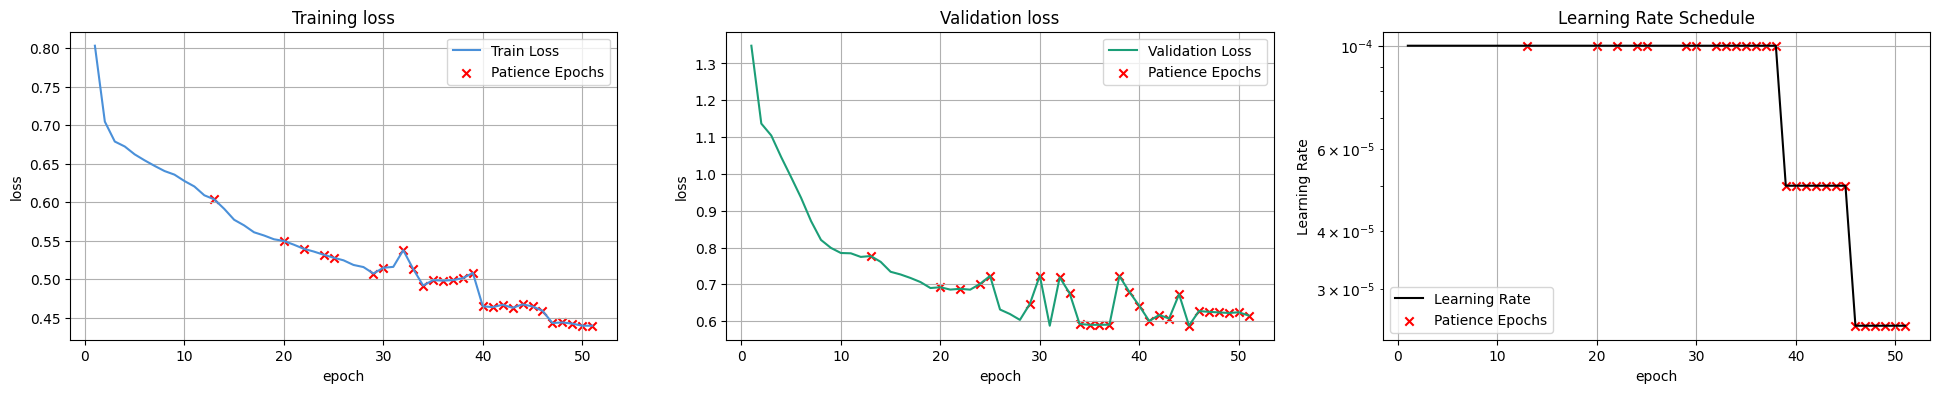

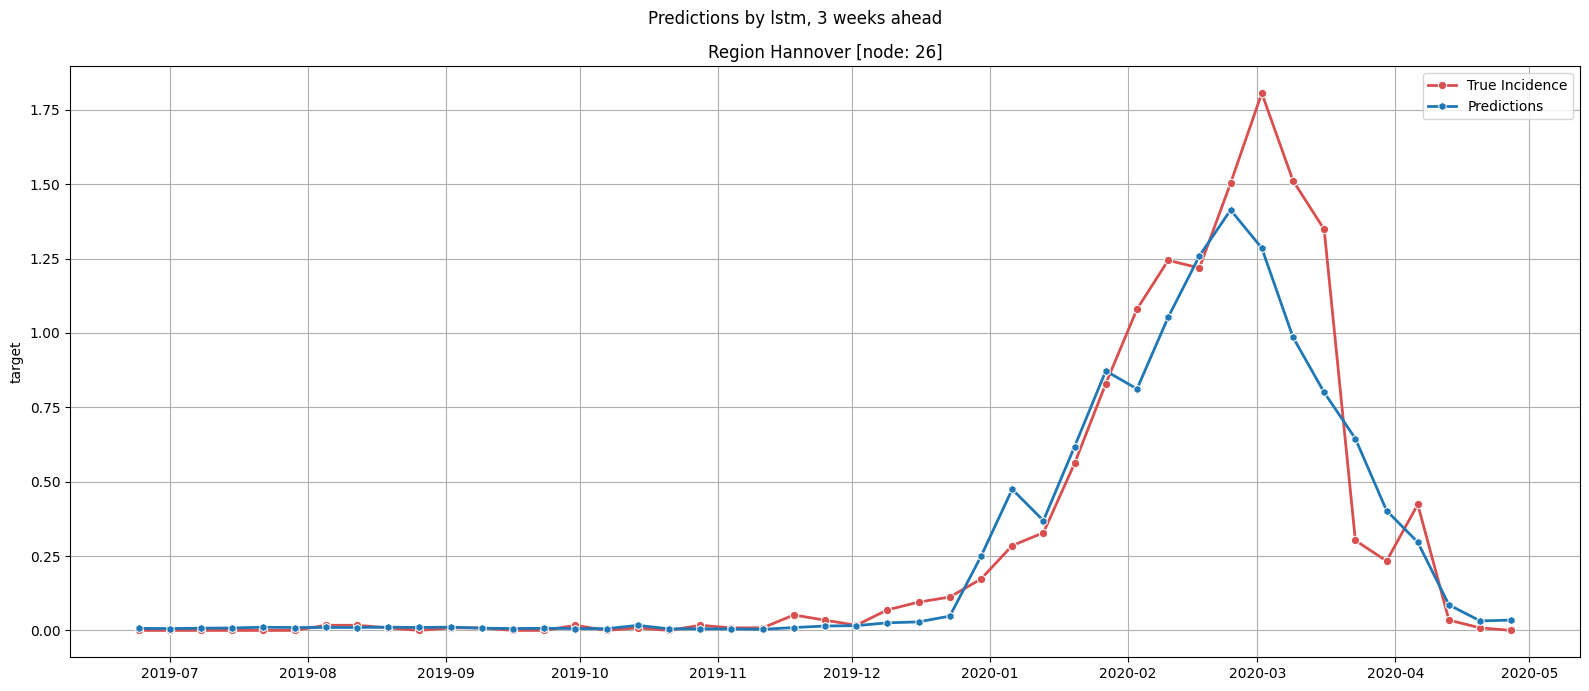

In [5]:
lstm = NodeLSTMModel(graphdataloader_id, name = 'lstm')
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train(verbose = 2)
lstm.forecast('test')
lstm.show_forecasts(26)

## GNNs


==                identity_graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7412, val loss: 1.3373 ✓ (new best)
Epoch 2 train loss: 0.7098, val loss: 1.1353 ✓ (new best)
Epoch 3 train loss: 0.6818, val loss: 1.0752 ✓ (new best)
Epoch 4 train loss: 0.6756, val loss: 1.0049 ✓ (new best)
Epoch 5 train loss: 0.6663, val loss: 0.9407 ✓ (new best)
Epoch 6 train loss: 0.6535, val loss: 0.9416 (patience: 1/20)
Epoch 7 train loss: 0.6554, val loss: 0.8234 ✓ (new best)
Epoch 8 train loss: 0.6429, val loss: 0.8946 (patience: 1/20)
Epoch 9 train loss: 0.6504, val loss: 0.7401 ✓ (new best)
Epoch 10 train loss: 0.6312, val loss: 0.8406 (patience: 1/20)
Epoch 11 train loss: 0.6422, val loss: 0.7333 ✓ (new best)
Epoch 12 train loss: 0.6228, val loss: 0.7733 (patience: 1/20)
Epoch 13 train loss: 0.6242, val loss: 0.7506 (patience: 2/20)
Epoch 14 train loss: 0.6199, val loss: 0.7376 (patience: 3/20)
Epoch 15

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 564.62it/s]

Test loss: 0.9000



==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.7557, val loss: 1.2822 ✓ (new best)
Epoch 2 train loss: 0.7080, val loss: 1.0483 ✓ (new best)
Epoch 3 train loss: 0.6774, val loss: 0.9736 ✓ (new best)
Epoch 4 train loss: 0.6618, val loss: 0.8503 ✓ (new best)
Epoch 5 train loss: 0.6417, val loss: 0.8193 ✓ (new best)
Epoch 6 train loss: 0.6425, val loss: 0.7887 ✓ (new best)
Epoch 7 train loss: 0.6331, val loss: 0.7633 ✓ (new best)
Epoch 8 train loss: 0.6223, val loss: 0.7525 ✓ (new best)
Epoch 9 train loss: 0.6142, val loss: 0.7348 ✓ (new best)
Epoch 10 train loss: 0.6039, val loss: 0.7302 ✓ (new best)
Epoch 11 train loss: 0.5934, val loss: 0.7047 ✓ (new best)
Epoch 12 train loss: 0.5884, val loss: 0.7163 (patience: 1/20)
Epoch 13 train loss: 0.5785, val loss: 0.6981 ✓ (new best)
Epoch 14 train loss: 0.5767, val loss: 0.7078 (patience: 1/20)
Epoch 15 train loss: 0

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 552.14it/s]

...

Test loss: 0.7662



==                  commuter 3                  ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2285), edge_weight=(2285,))
Epoch 1 train loss: 0.7412, val loss: 1.2580 ✓ (new best)
Epoch 2 train loss: 0.6953, val loss: 1.0331 ✓ (new best)
Epoch 3 train loss: 0.6750, val loss: 0.9309 ✓ (new best)
Epoch 4 train loss: 0.6581, val loss: 0.8389 ✓ (new best)
Epoch 5 train loss: 0.6548, val loss: 0.8047 ✓ (new best)
Epoch 6 train loss: 0.6440, val loss: 0.7642 ✓ (new best)
Epoch 7 train loss: 0.6393, val loss: 0.7486 ✓ (new best)
Epoch 8 train loss: 0.6297, val loss: 0.7202 ✓ (new best)
Epoch 9 train loss: 0.6187, val loss: 0.7106 ✓ (new best)
Epoch 10 train loss: 0.6155, val loss: 0.6864 ✓ (new best)
Epoch 11 train loss: 0.6022, val loss: 0.6796 ✓ (new best)
Epoch 12 train loss: 0.5962, val loss: 0.6531 ✓ (new best)
Epoch 13 train loss: 0.5894, val loss: 0.6459 ✓ (new best)
Epoch 14 train loss: 0.5852, val loss: 0.6415 ✓ (new best)
Epoch 15 train loss: 0.5737, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 549.84it/s]

Test loss: 0.7958


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

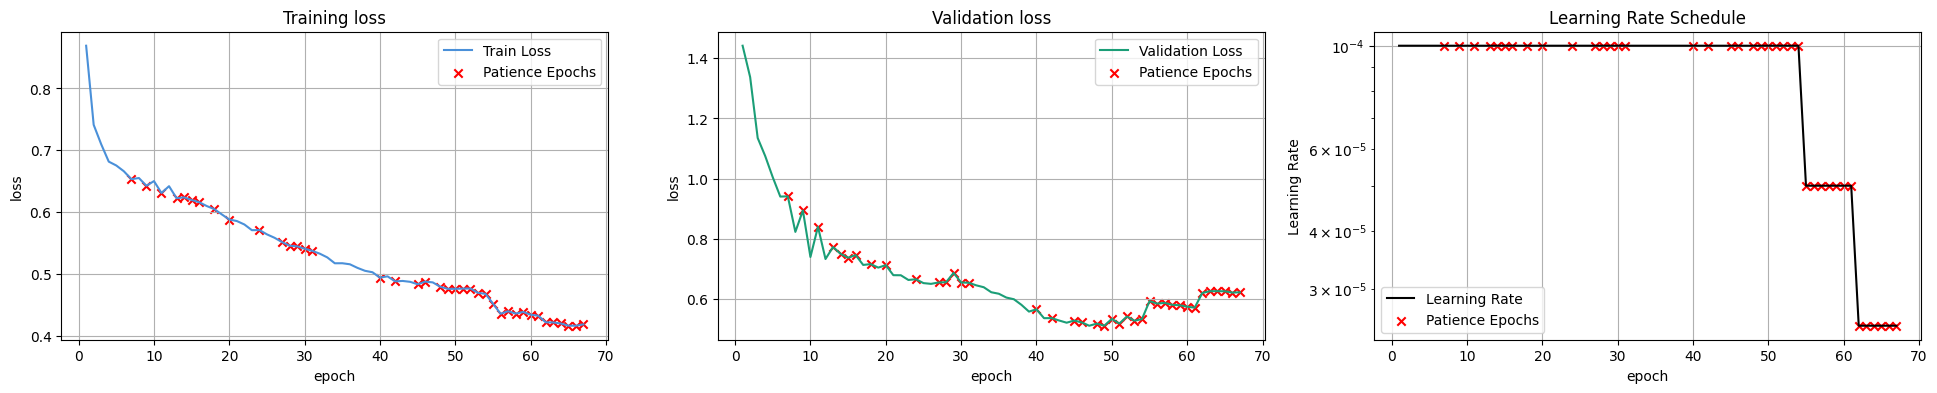

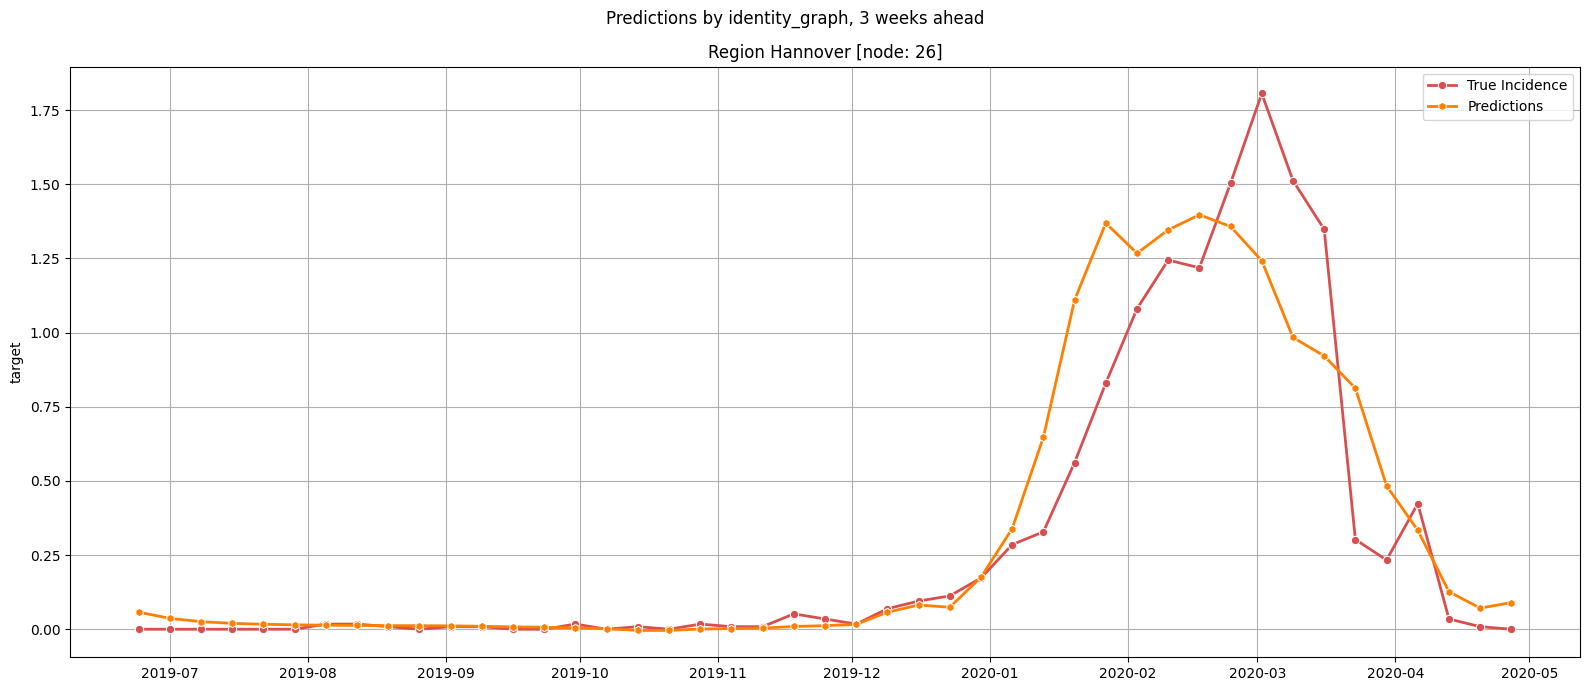

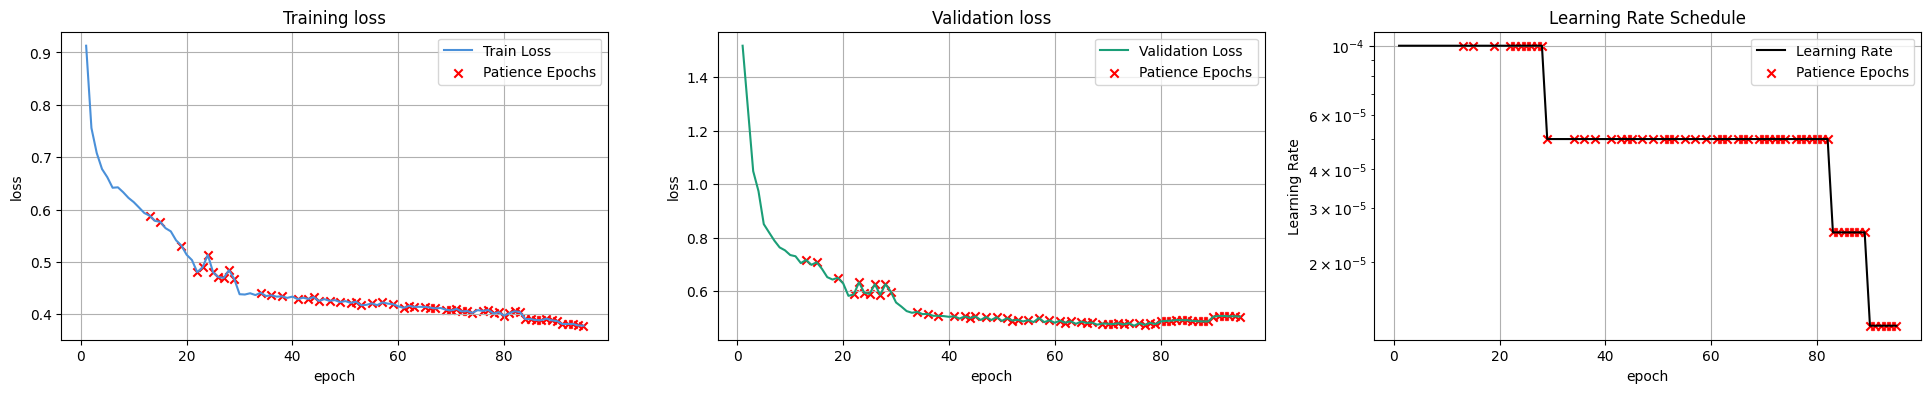

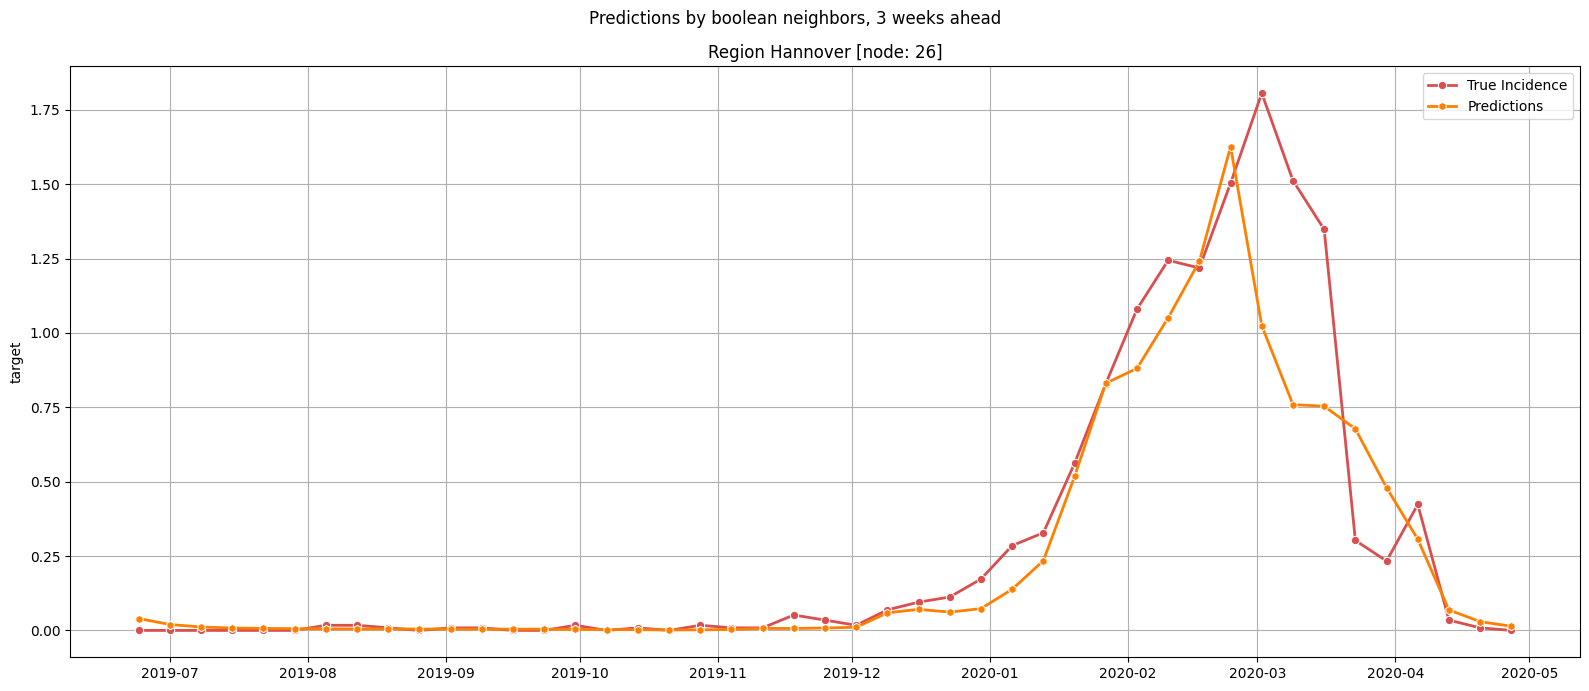

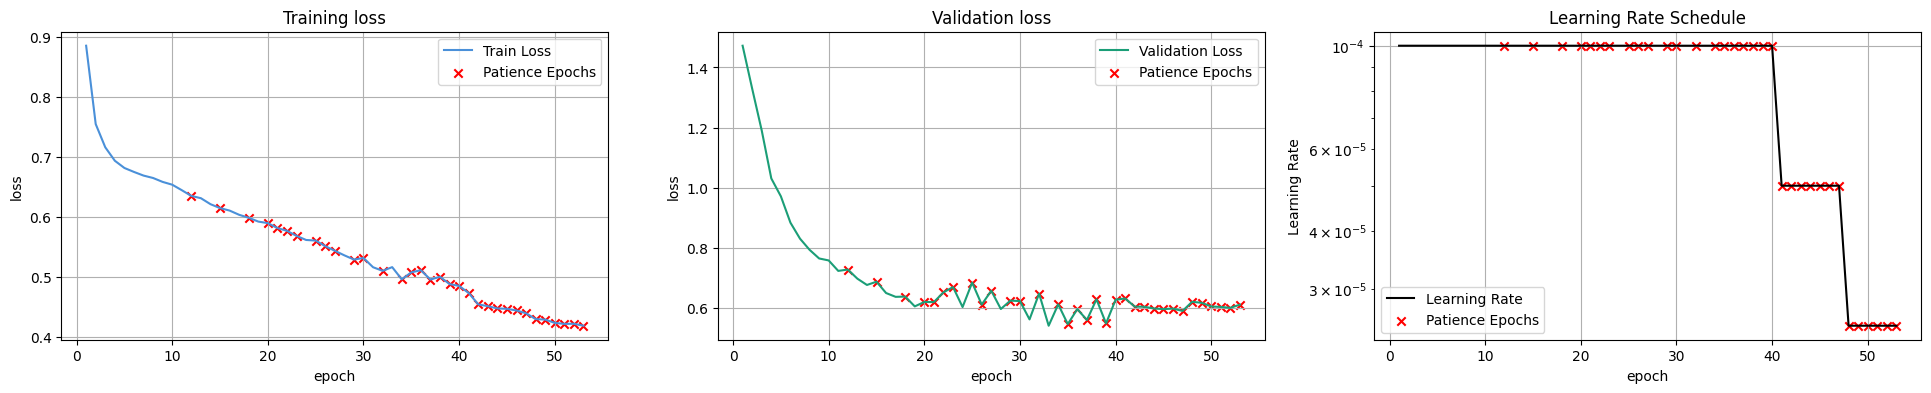

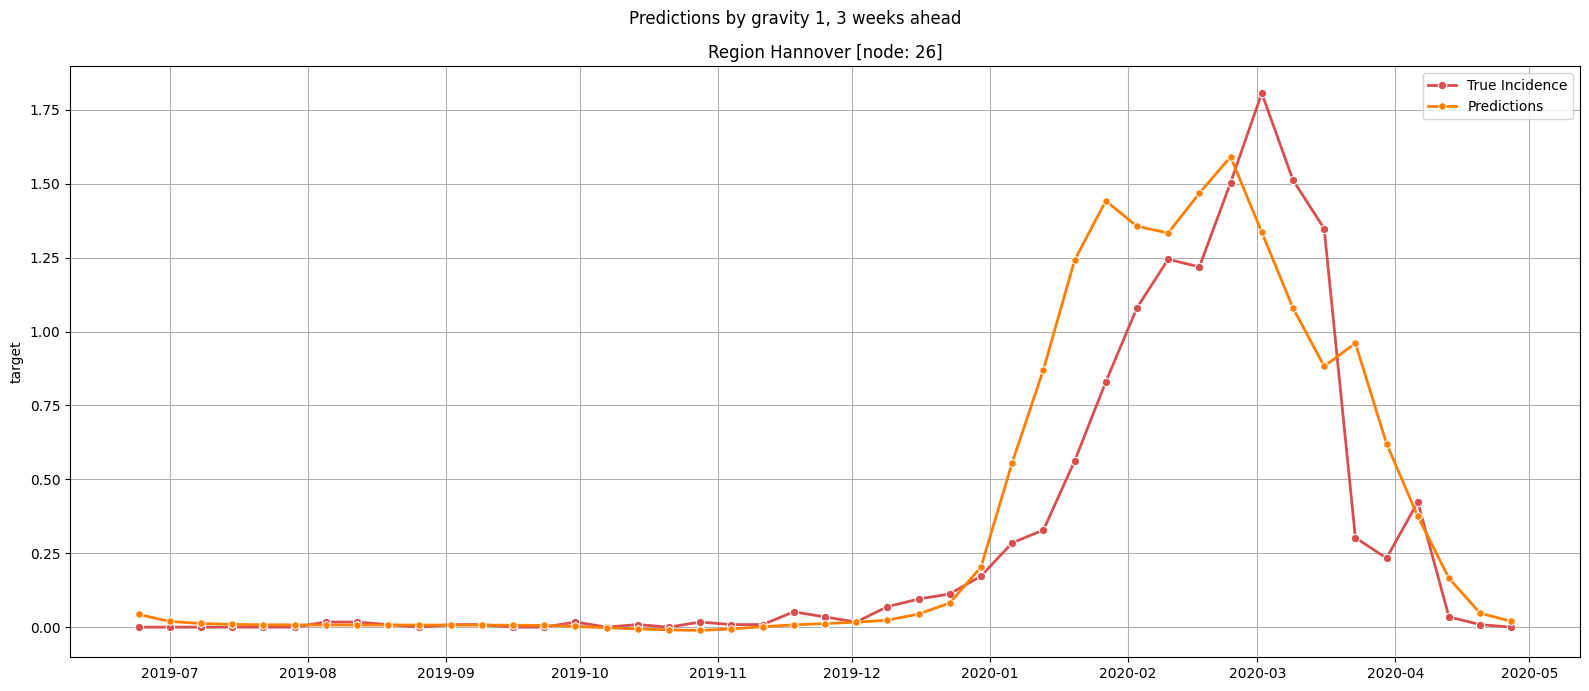

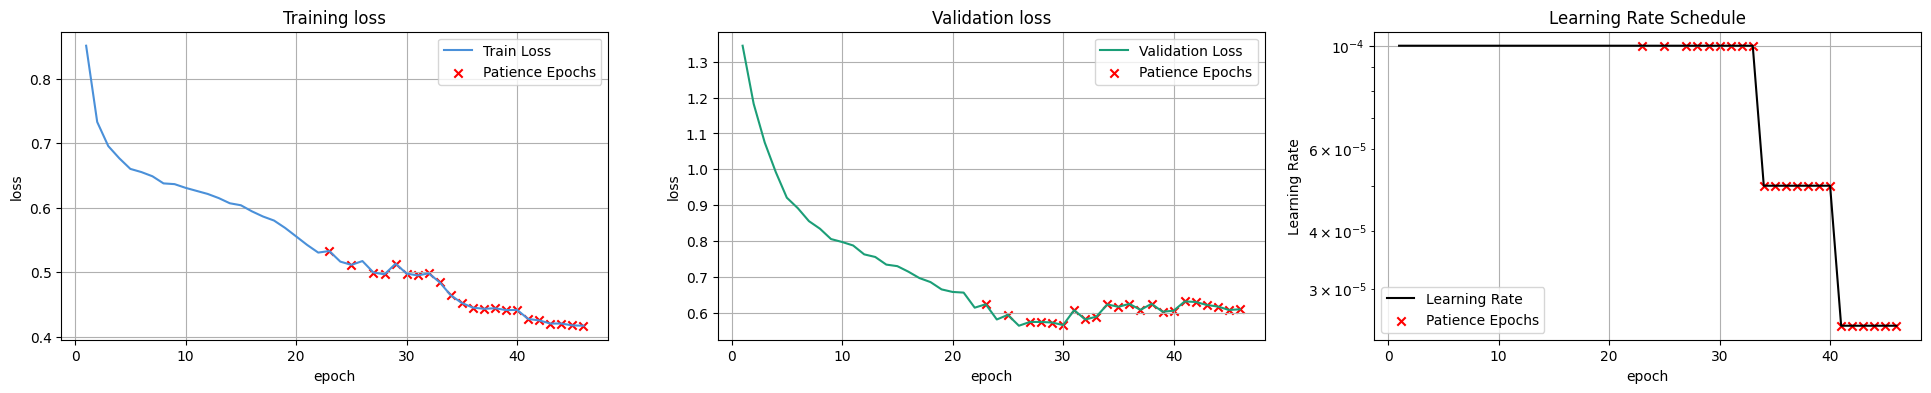

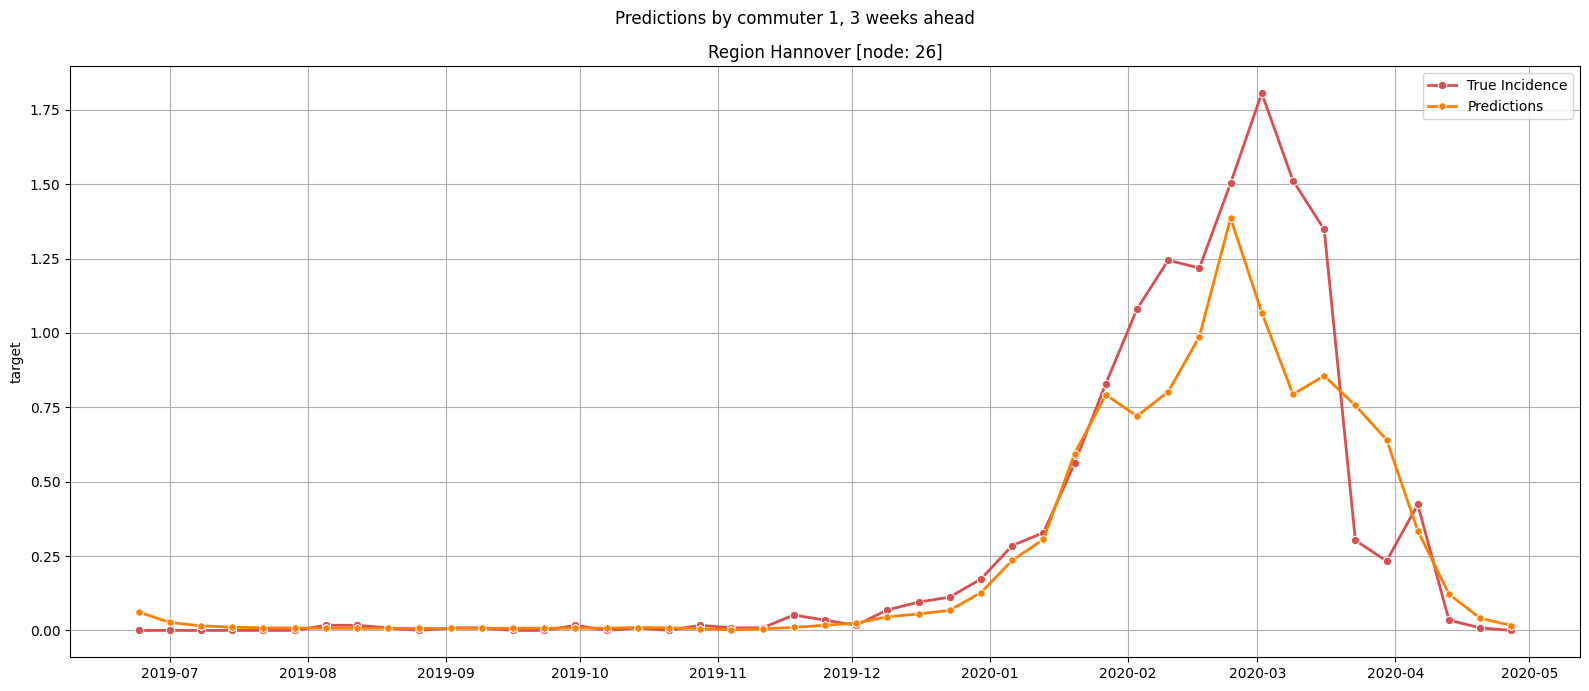

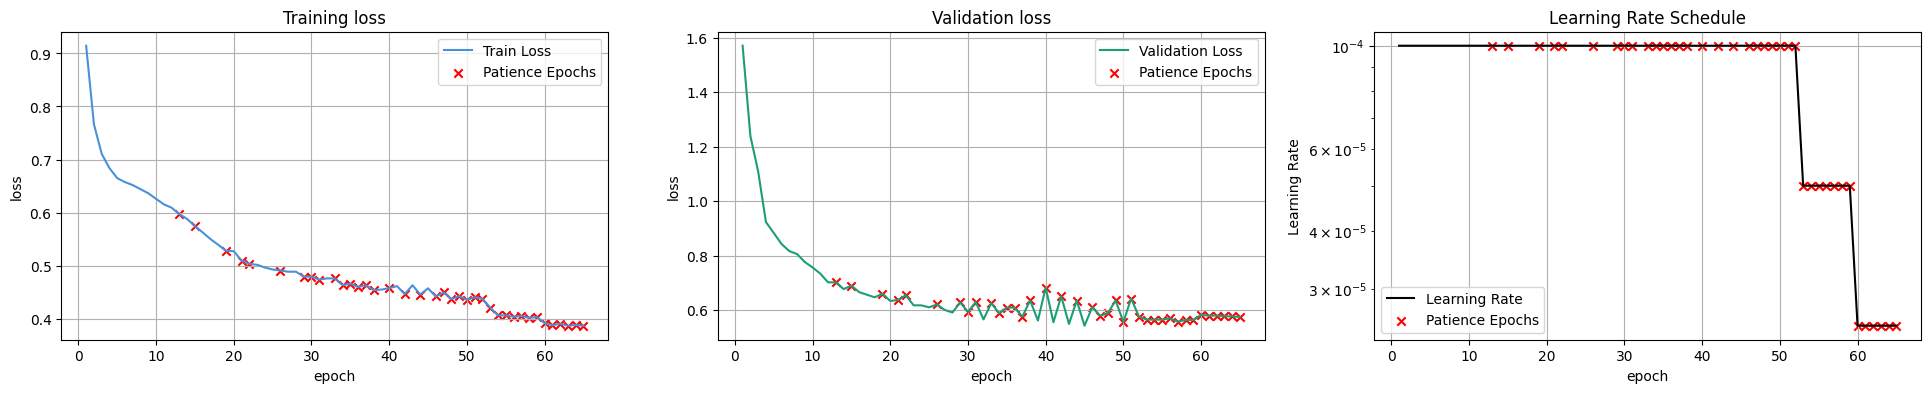

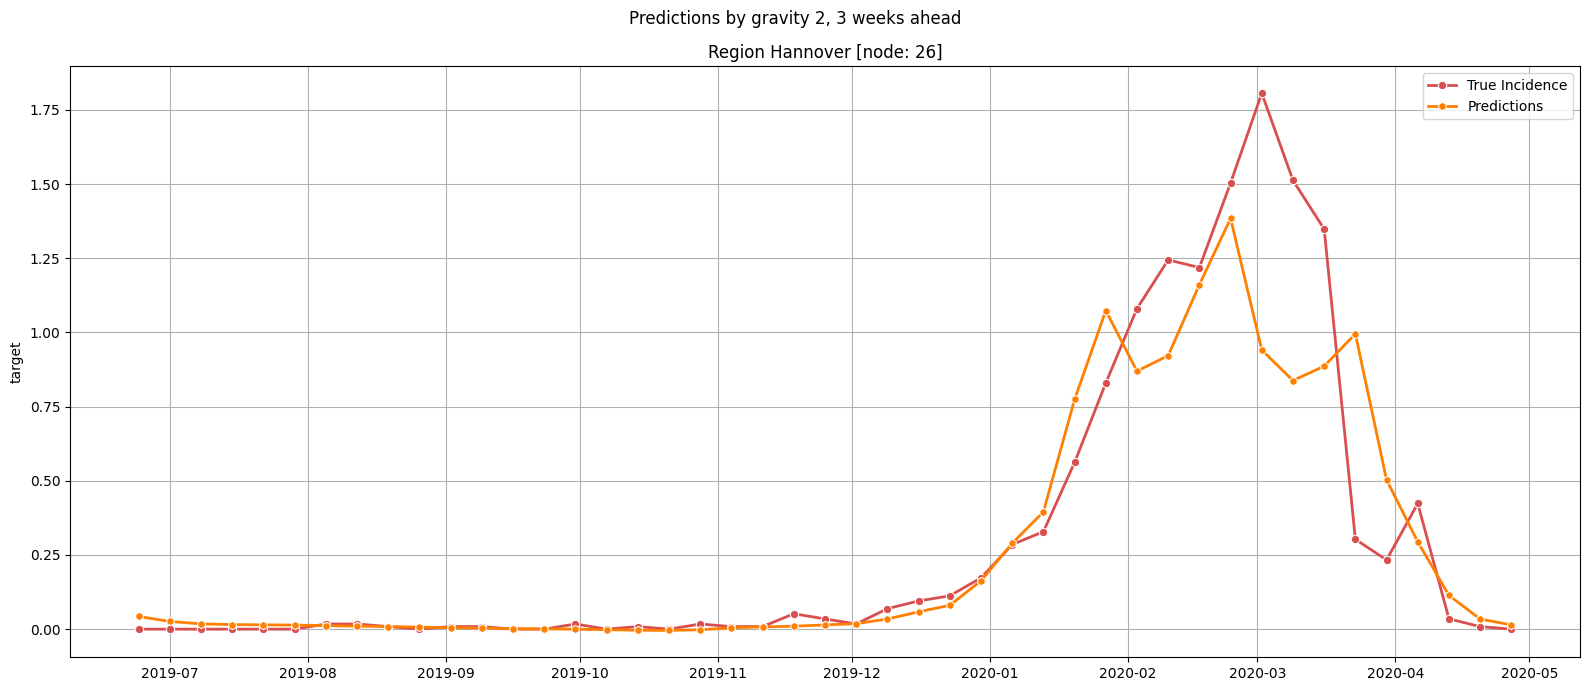

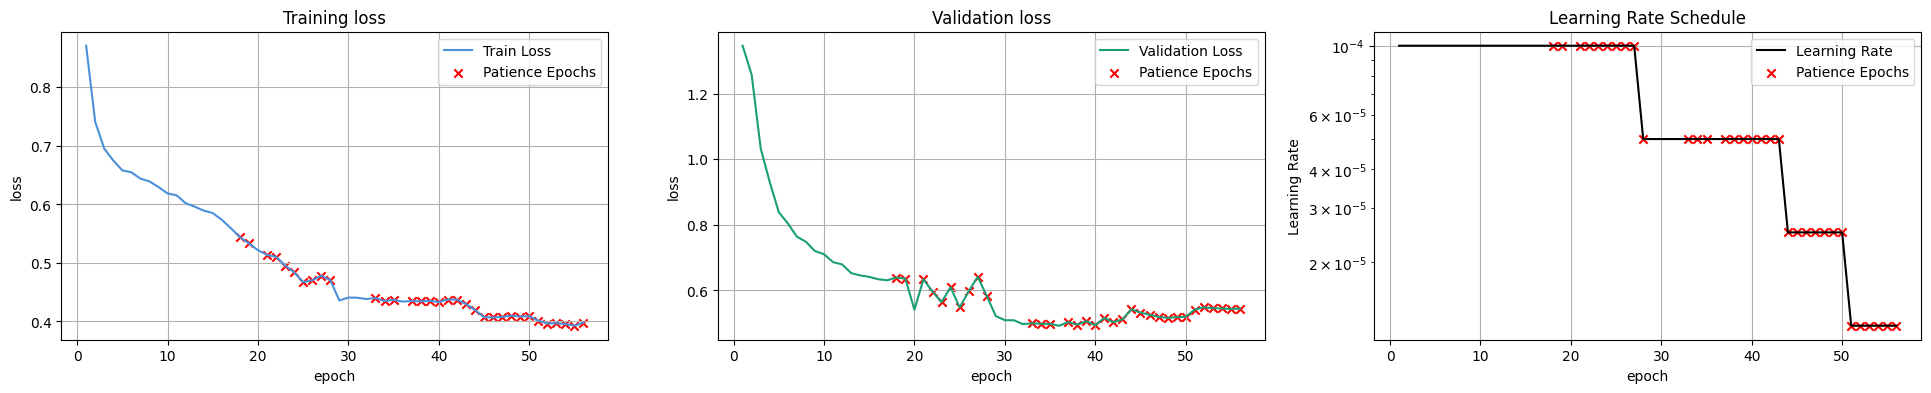

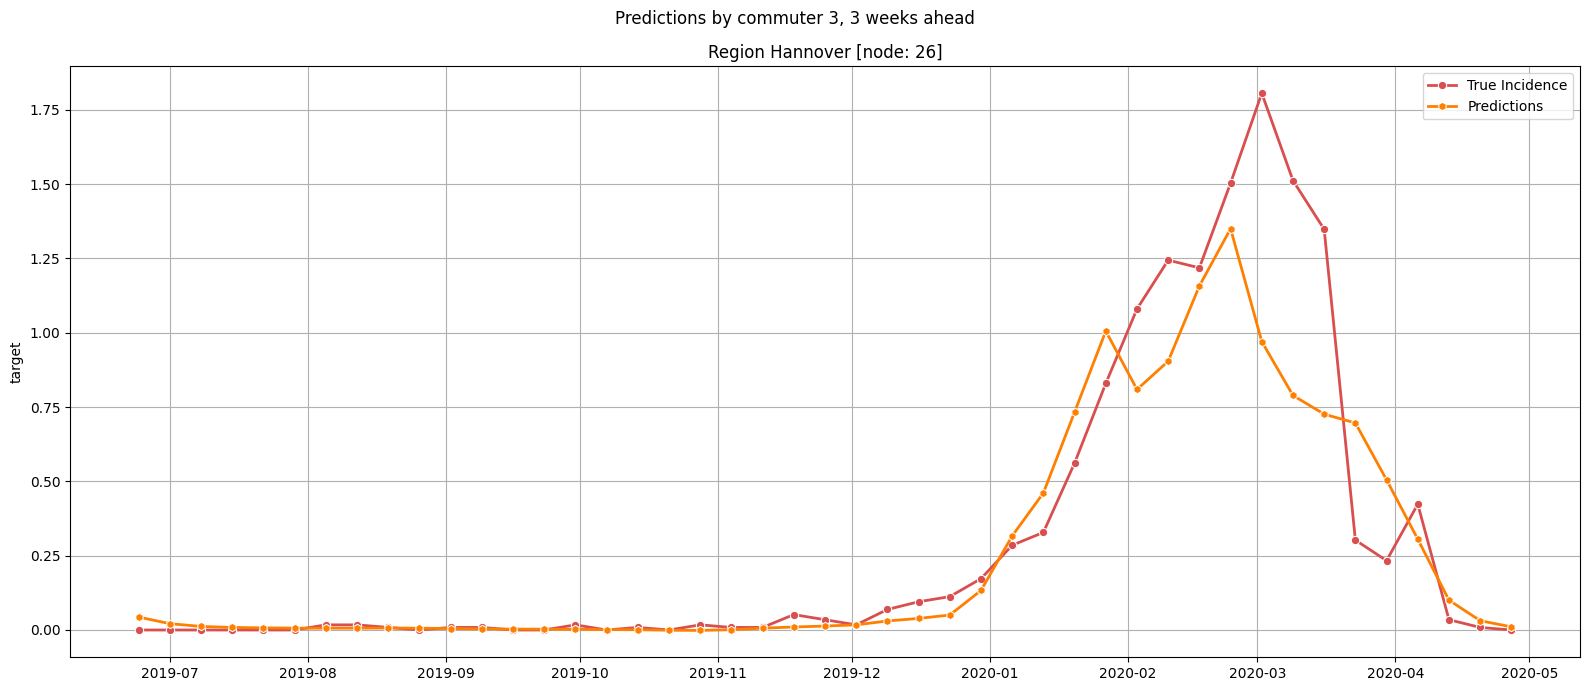

In [6]:
spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'identity_graph')
spatiotemporal_model1.set_model_hparams()
spatiotemporal_model1.set_global_hparams(**global_hparams)
spatiotemporal_model1.train(verbose = 2)
spatiotemporal_model1.forecast('test')
spatiotemporal_model1.show_forecasts(26)

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'boolean neighbors')
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train(verbose = 2)
spatiotemporal_model2.forecast('test')
spatiotemporal_model2.show_forecasts(26)

spatiotemporal_model3 = GATv2Model(graphdataloader_gr1, name = 'gravity 1')
spatiotemporal_model3.set_model_hparams()
spatiotemporal_model3.set_global_hparams(**global_hparams)
spatiotemporal_model3.train(verbose = 2)
spatiotemporal_model3.forecast('test')
spatiotemporal_model3.show_forecasts(26)

spatiotemporal_model4 = GATv2Model(graphdataloader_cm1, name = 'commuter 1')
spatiotemporal_model4.set_model_hparams()
spatiotemporal_model4.set_global_hparams(**global_hparams)
spatiotemporal_model4.train(verbose = 2)
spatiotemporal_model4.forecast('test')
spatiotemporal_model4.show_forecasts(26)

spatiotemporal_model5 = GATv2Model(graphdataloader_gr2, name = 'gravity 2')
spatiotemporal_model5.set_model_hparams()
spatiotemporal_model5.set_global_hparams(**global_hparams)
spatiotemporal_model5.train(verbose = 2)
spatiotemporal_model5.forecast('test')
spatiotemporal_model5.show_forecasts(26)

spatiotemporal_model6 = GATv2Model(graphdataloader_cm2, name = 'commuter 3')
spatiotemporal_model6.set_model_hparams()
spatiotemporal_model6.set_global_hparams(**global_hparams)
spatiotemporal_model6.train(verbose = 2)
spatiotemporal_model6.forecast('test')
spatiotemporal_model6.show_forecasts(26)


==                identity_graph                ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7414, val loss: 1.4608 ✓ (new best)
Epoch 2 train loss: 0.6579, val loss: 1.2268 ✓ (new best)
Epoch 3 train loss: 0.6352, val loss: 1.1358 ✓ (new best)
Epoch 4 train loss: 0.6182, val loss: 1.0703 ✓ (new best)
Epoch 5 train loss: 0.6105, val loss: 1.0223 ✓ (new best)
Epoch 6 train loss: 0.6044, val loss: 0.9796 ✓ (new best)
Epoch 7 train loss: 0.5982, val loss: 0.9427 ✓ (new best)
Epoch 8 train loss: 0.5929, val loss: 0.9094 ✓ (new best)
Epoch 9 train loss: 0.5919, val loss: 0.8860 ✓ (new best)
Epoch 10 train loss: 0.5861, val loss: 0.8601 ✓ (new best)
Epoch 11 train loss: 0.5846, val loss: 0.8441 ✓ (new best)
Epoch 12 train loss: 0.5814, val loss: 0.8272 ✓ (new best)
Epoch 13 train loss: 0.5796, val loss: 0.8117 ✓ (new best)
Epoch 14 train loss: 0.5783, val loss: 0.7995 ✓ (new best)
Epoch 15 train loss: 0.5778, val

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 618.74it/s]


Test loss: 1.0520

==              boolean neighbors               ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.7268, val loss: 1.4074 ✓ (new best)
Epoch 2 train loss: 0.6550, val loss: 1.2127 ✓ (new best)
Epoch 3 train loss: 0.6326, val loss: 1.1359 ✓ (new best)
Epoch 4 train loss: 0.6220, val loss: 1.0850 ✓ (new best)
Epoch 5 train loss: 0.6155, val loss: 1.0500 ✓ (new best)
Epoch 6 train loss: 0.6087, val loss: 1.0172 ✓ (new best)
Epoch 7 train loss: 0.6014, val loss: 0.9873 ✓ (new best)
Epoch 8 train loss: 0.5978, val loss: 0.9638 ✓ (new best)
Epoch 9 train loss: 0.5954, val loss: 0.9423 ✓ (new best)
Epoch 10 train loss: 0.5923, val loss: 0.9244 ✓ (new best)
Epoch 11 train loss: 0.5887, val loss: 0.9073 ✓ (new best)
Epoch 12 train loss: 0.5854, val loss: 0.8908 ✓ (new best)
Epoch 13 train loss: 0.5842, val loss: 0.8797 ✓ (new best)
Epoch 14 train loss: 0.5808, val loss: 0.8666 ✓ (new best)
Epoch 15 tra

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 606.52it/s]

Test loss: 0.9063


...

Test loss: 0.9313



==                  commuter 3                  ==
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 2), edge_index=(2, 2285), edge_weight=(2285,))
Epoch 1 train loss: 0.7502, val loss: 1.4295 ✓ (new best)
Epoch 2 train loss: 0.6638, val loss: 1.2373 ✓ (new best)
Epoch 3 train loss: 0.6433, val loss: 1.1527 ✓ (new best)
Epoch 4 train loss: 0.6309, val loss: 1.0947 ✓ (new best)
Epoch 5 train loss: 0.6228, val loss: 1.0475 ✓ (new best)
Epoch 6 train loss: 0.6156, val loss: 1.0107 ✓ (new best)
Epoch 7 train loss: 0.6095, val loss: 0.9776 ✓ (new best)
Epoch 8 train loss: 0.6071, val loss: 0.9503 ✓ (new best)
Epoch 9 train loss: 0.6018, val loss: 0.9219 ✓ (new best)
Epoch 10 train loss: 0.5987, val loss: 0.8988 ✓ (new best)
Epoch 11 train loss: 0.5950, val loss: 0.8766 ✓ (new best)
Epoch 12 train loss: 0.5909, val loss: 0.8592 ✓ (new best)
Epoch 13 train loss: 0.5888, val loss: 0.8426 ✓ (new best)
Epoch 14 train loss: 0.5863, val loss: 0.8279 ✓ (new best)
Epoch 15 train loss: 0.5846, v

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 618.91it/s]

Test loss: 0.9679


(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>])

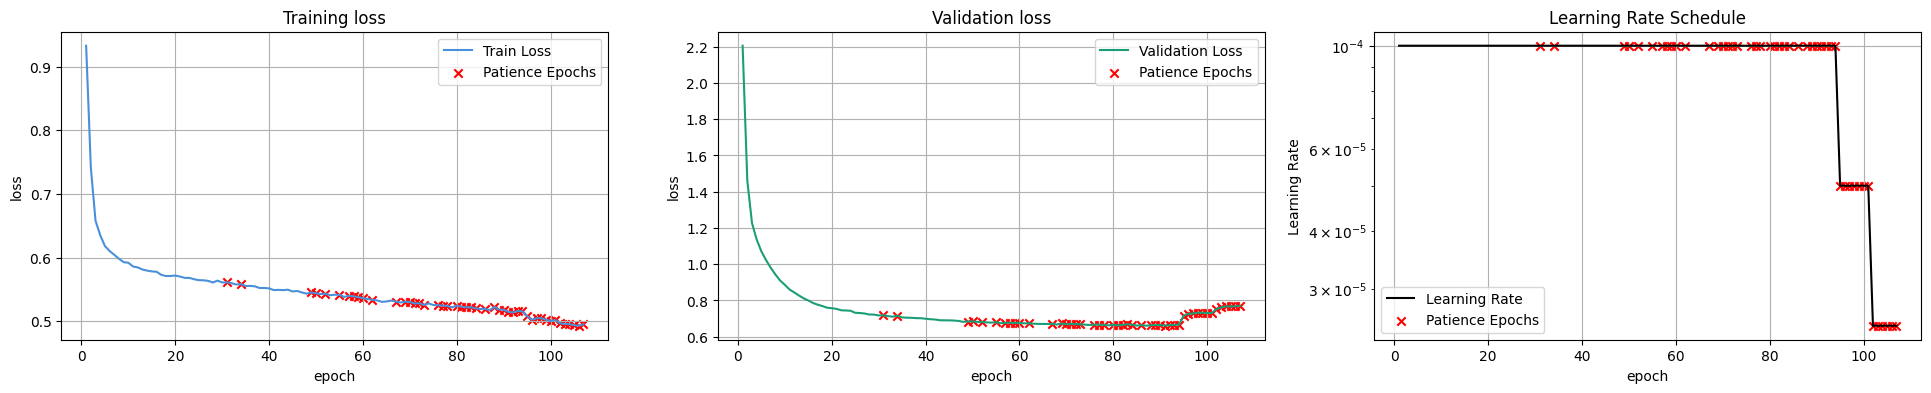

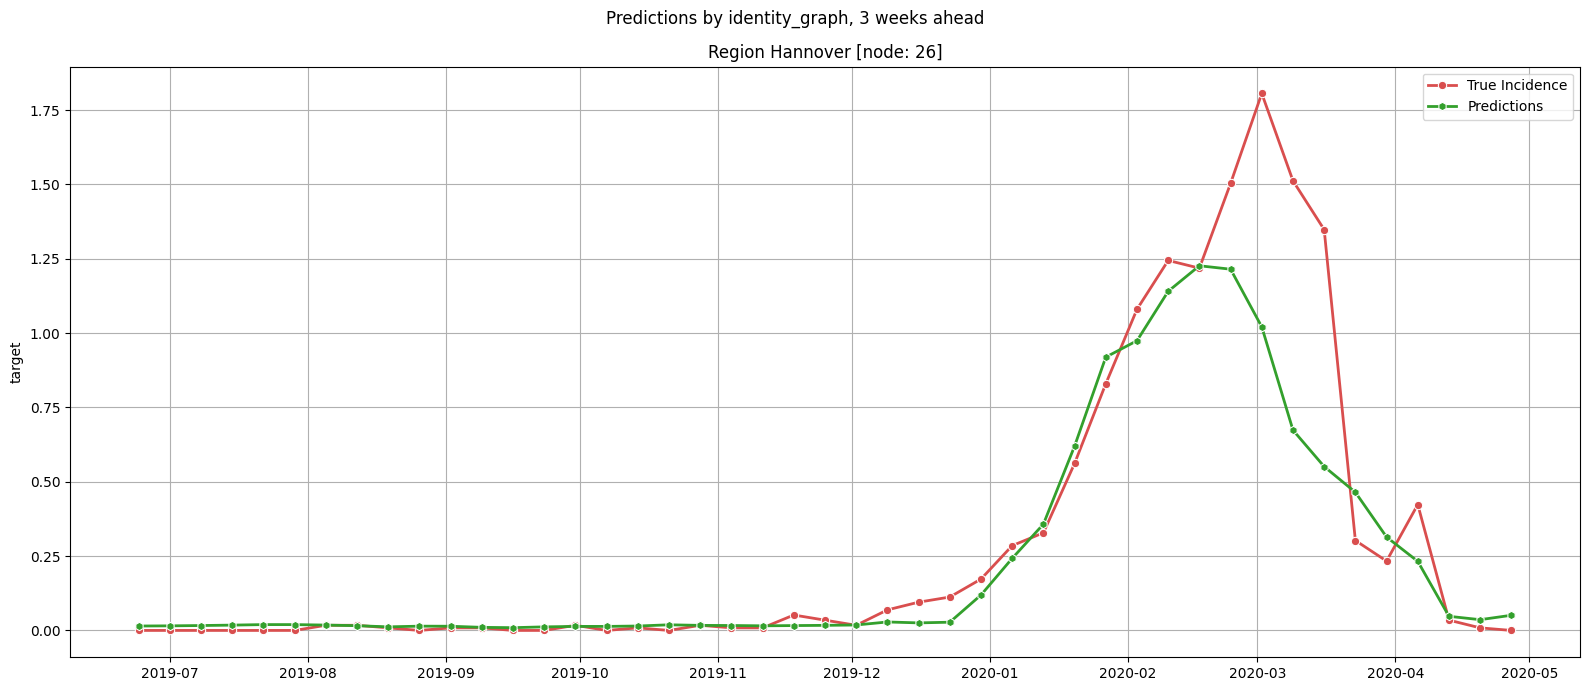

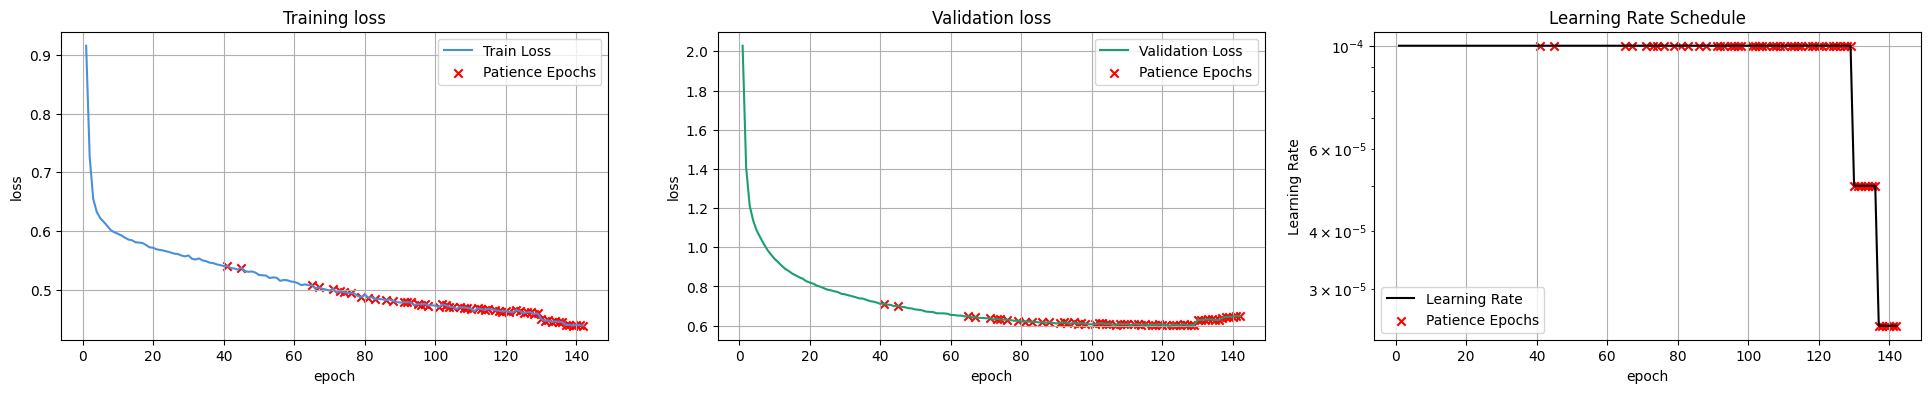

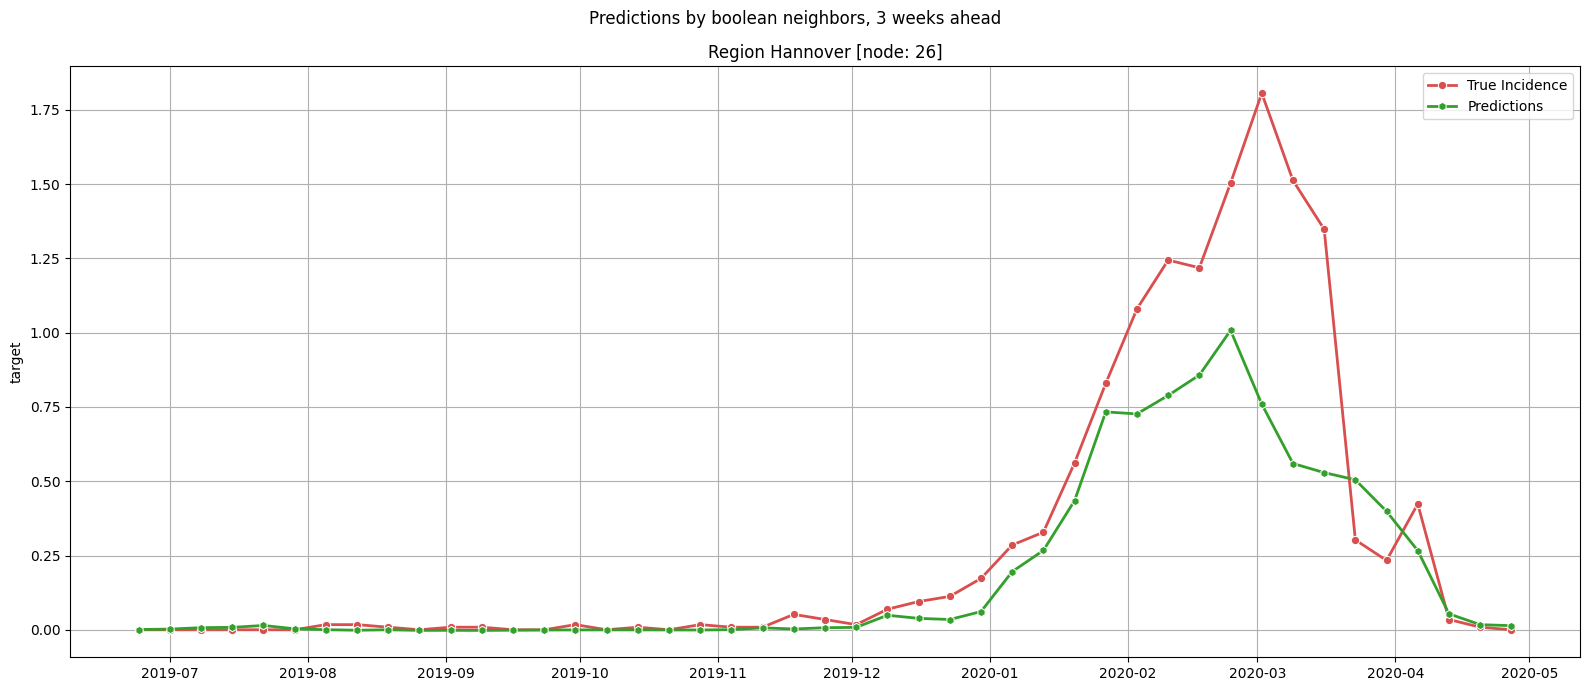

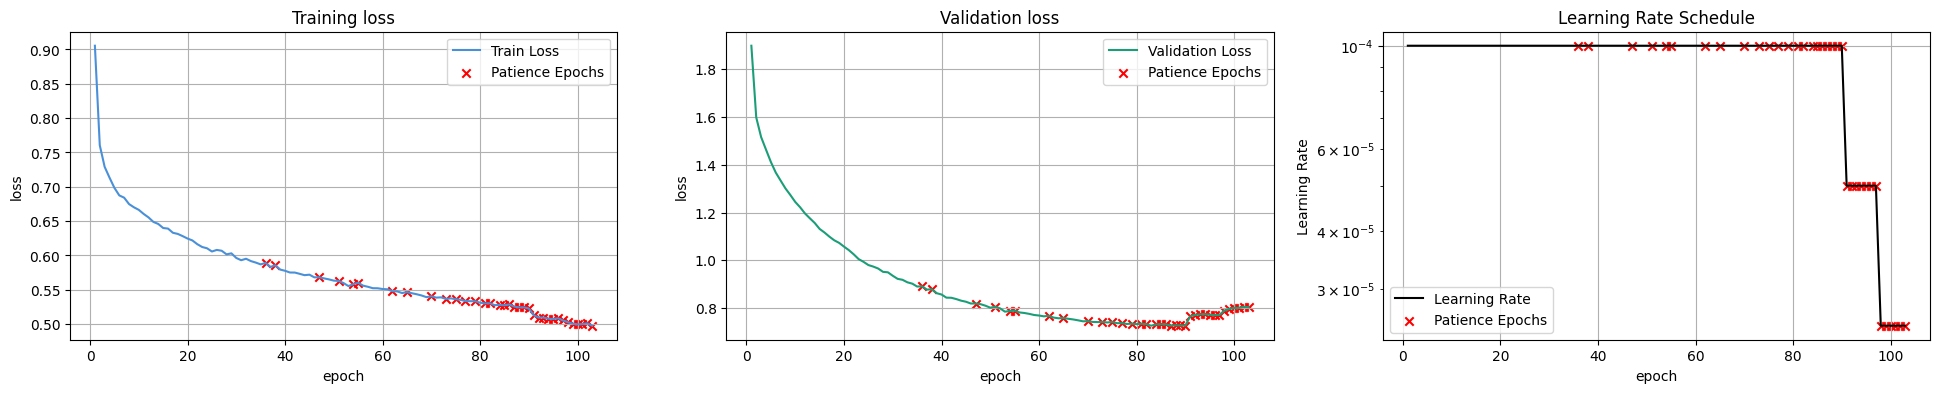

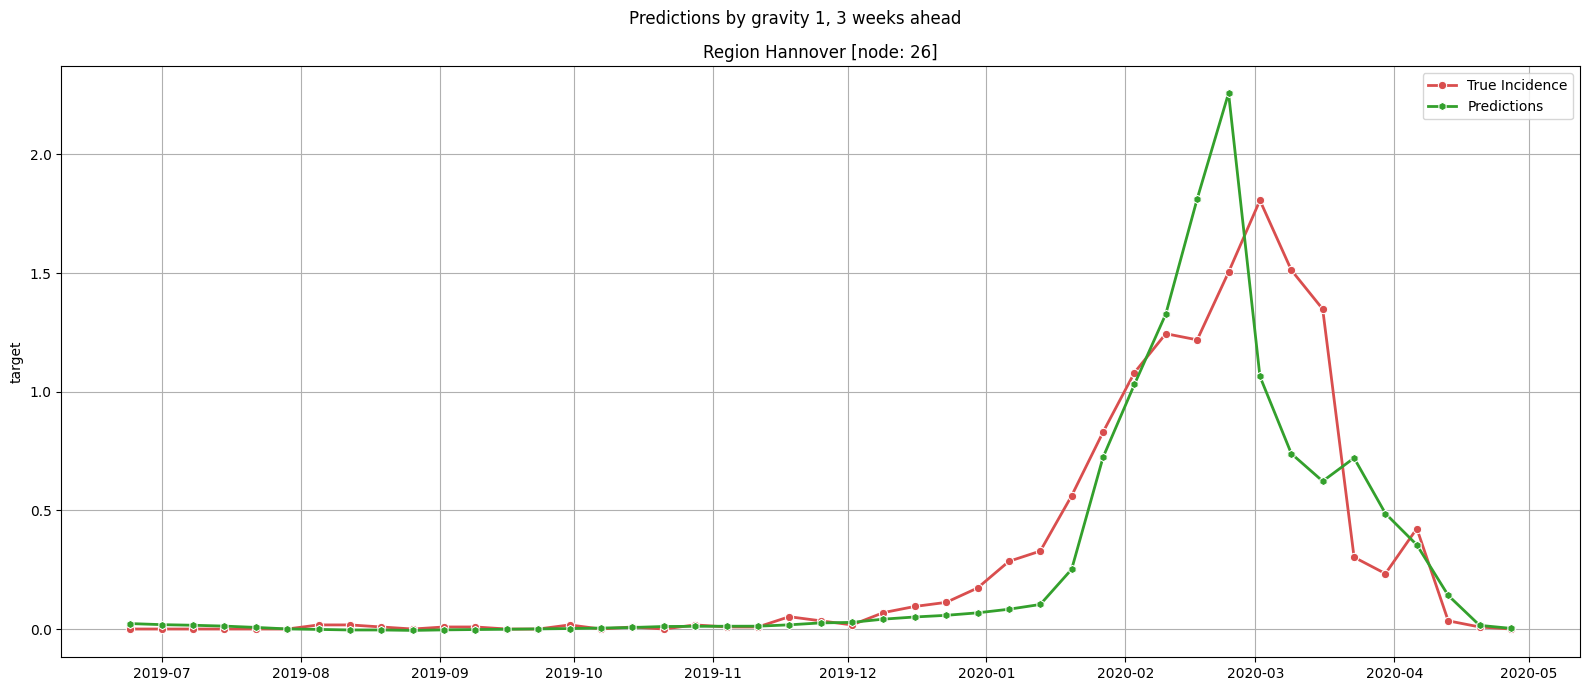

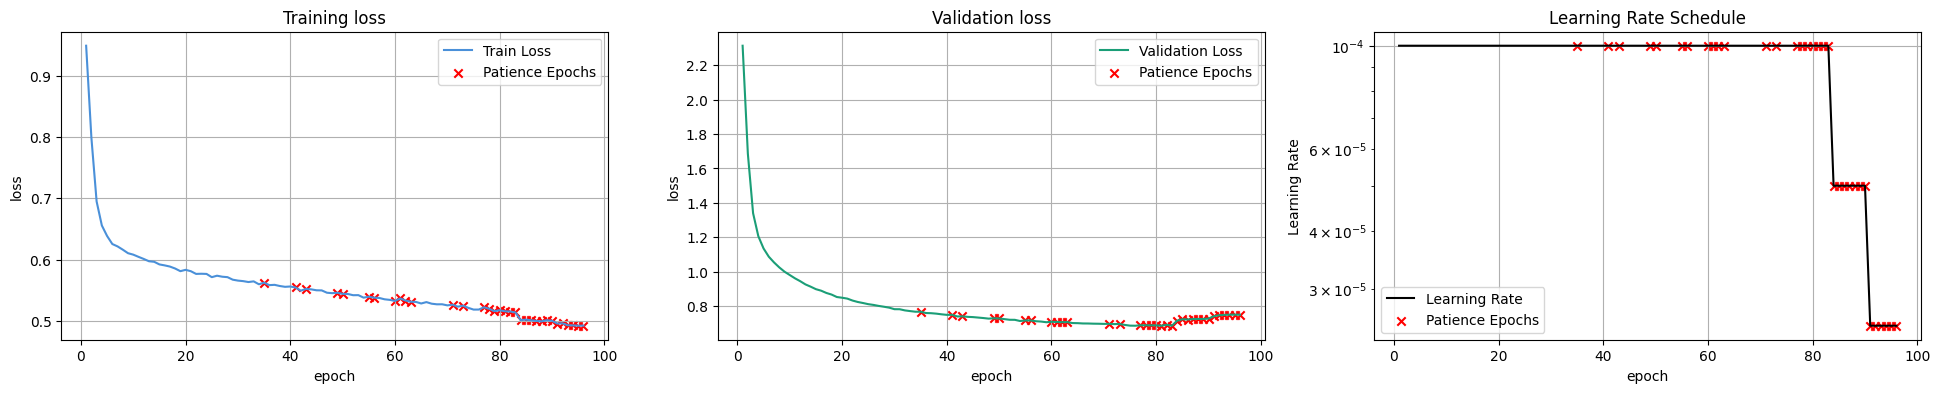

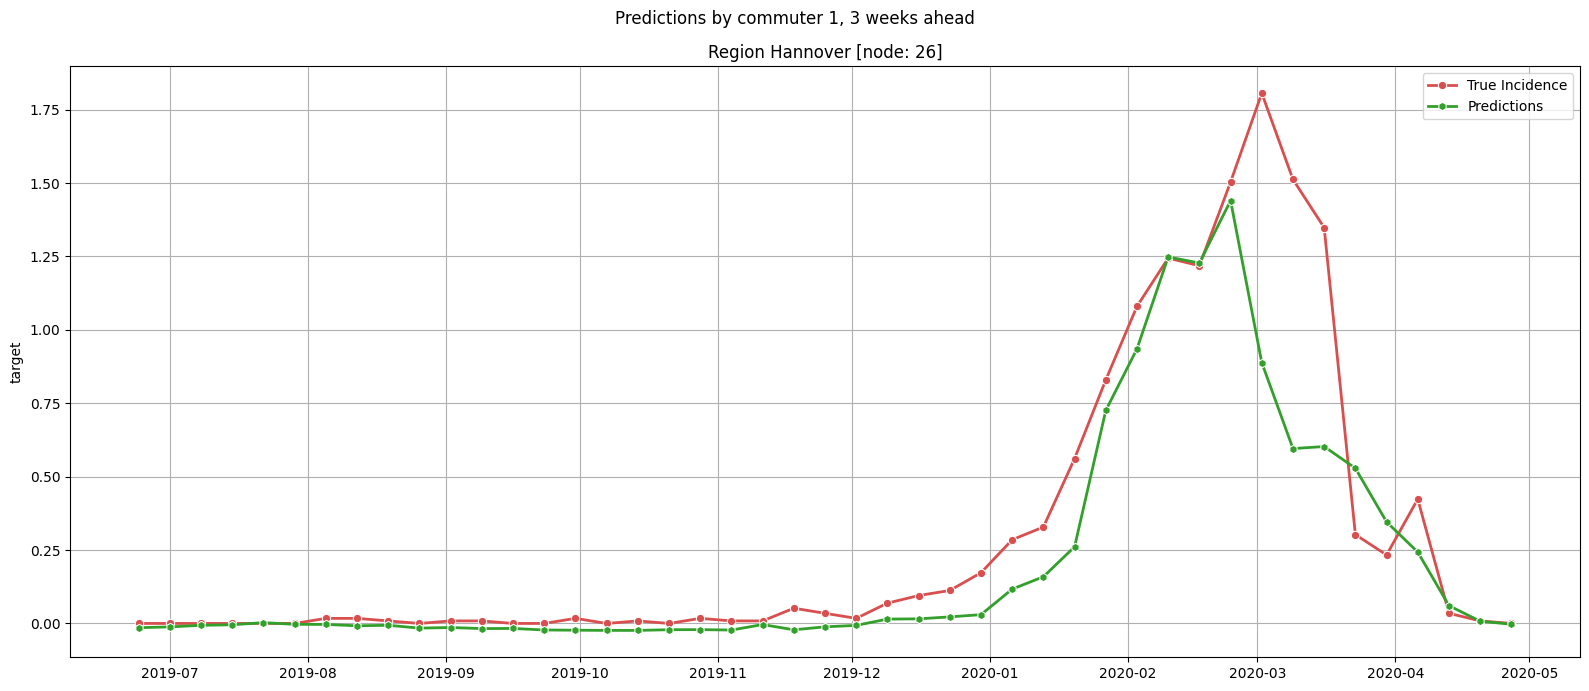

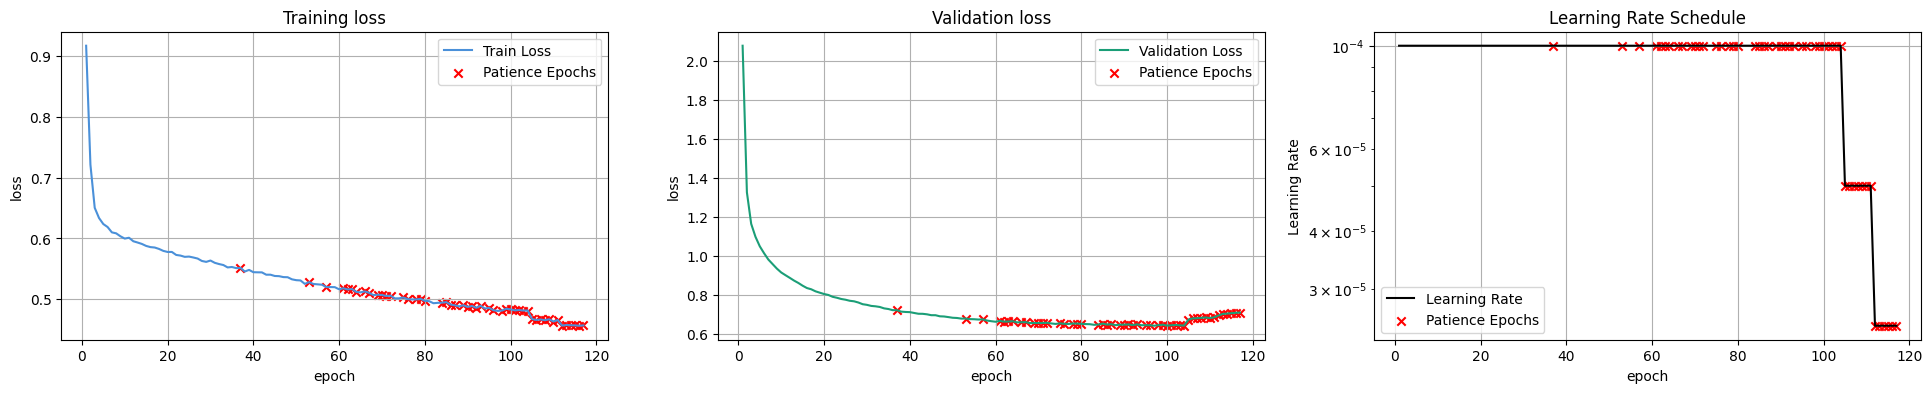

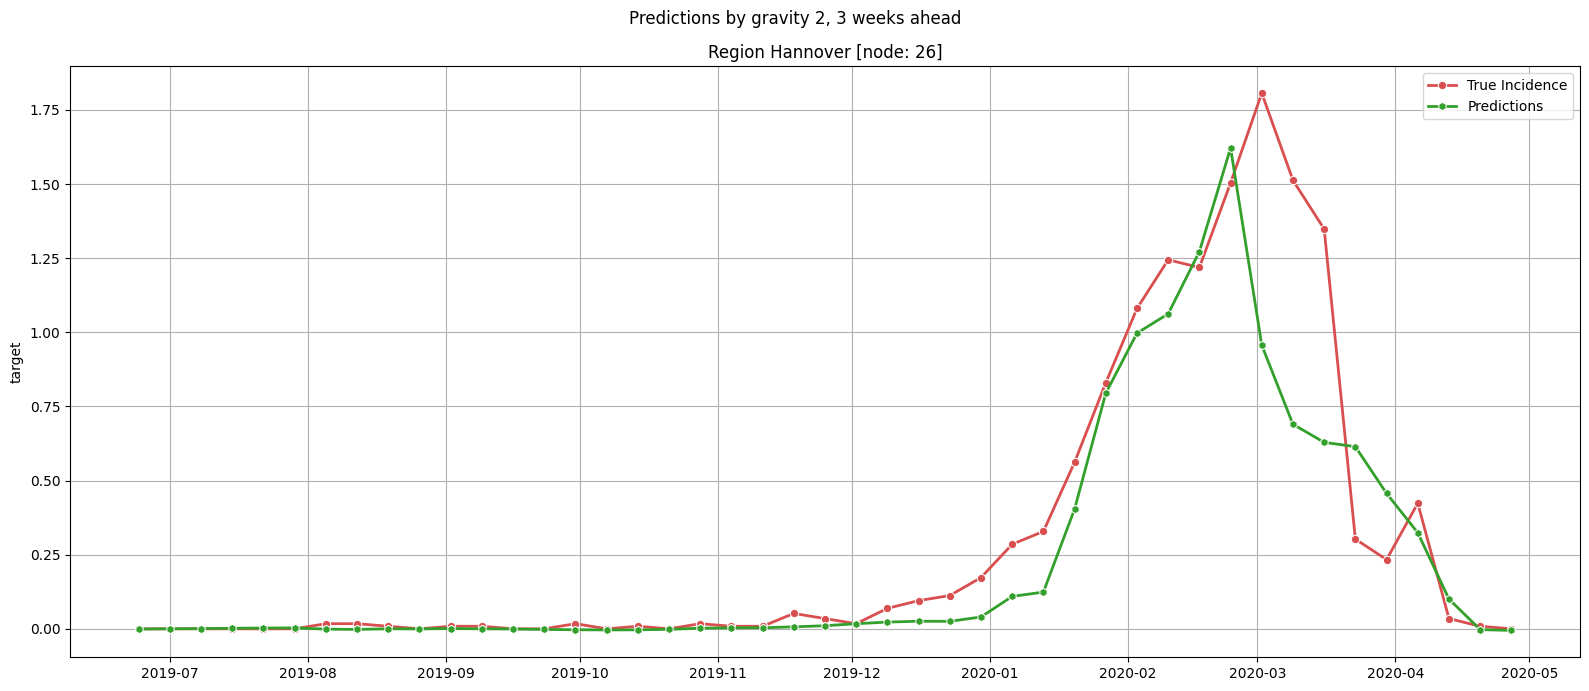

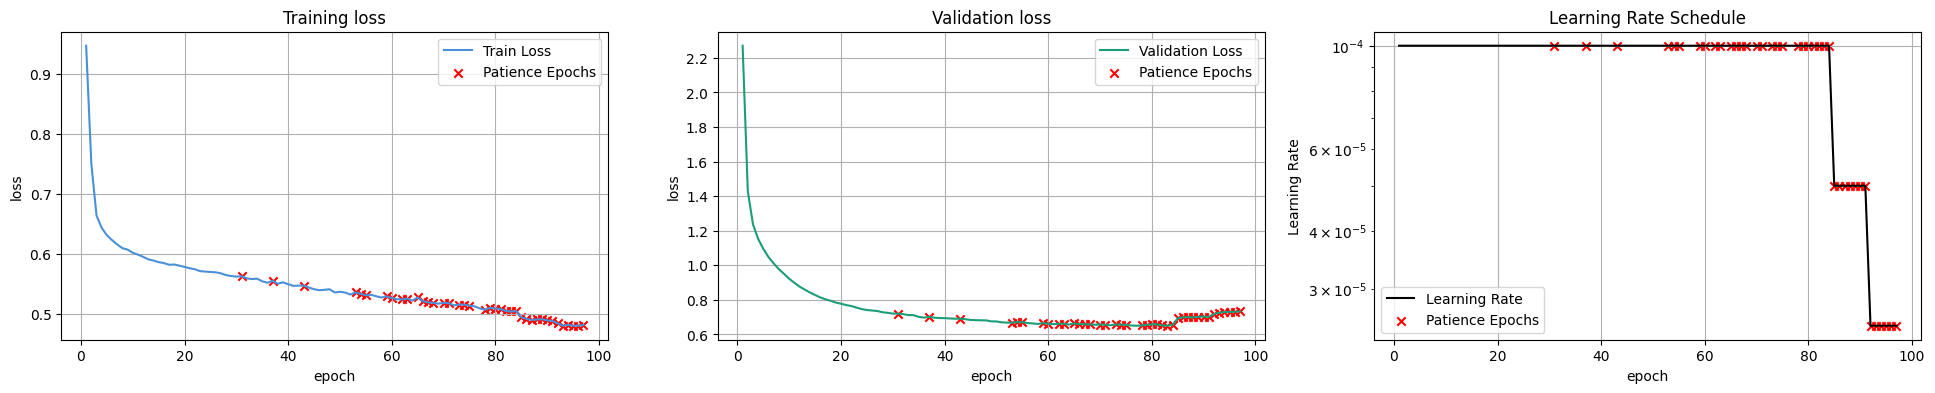

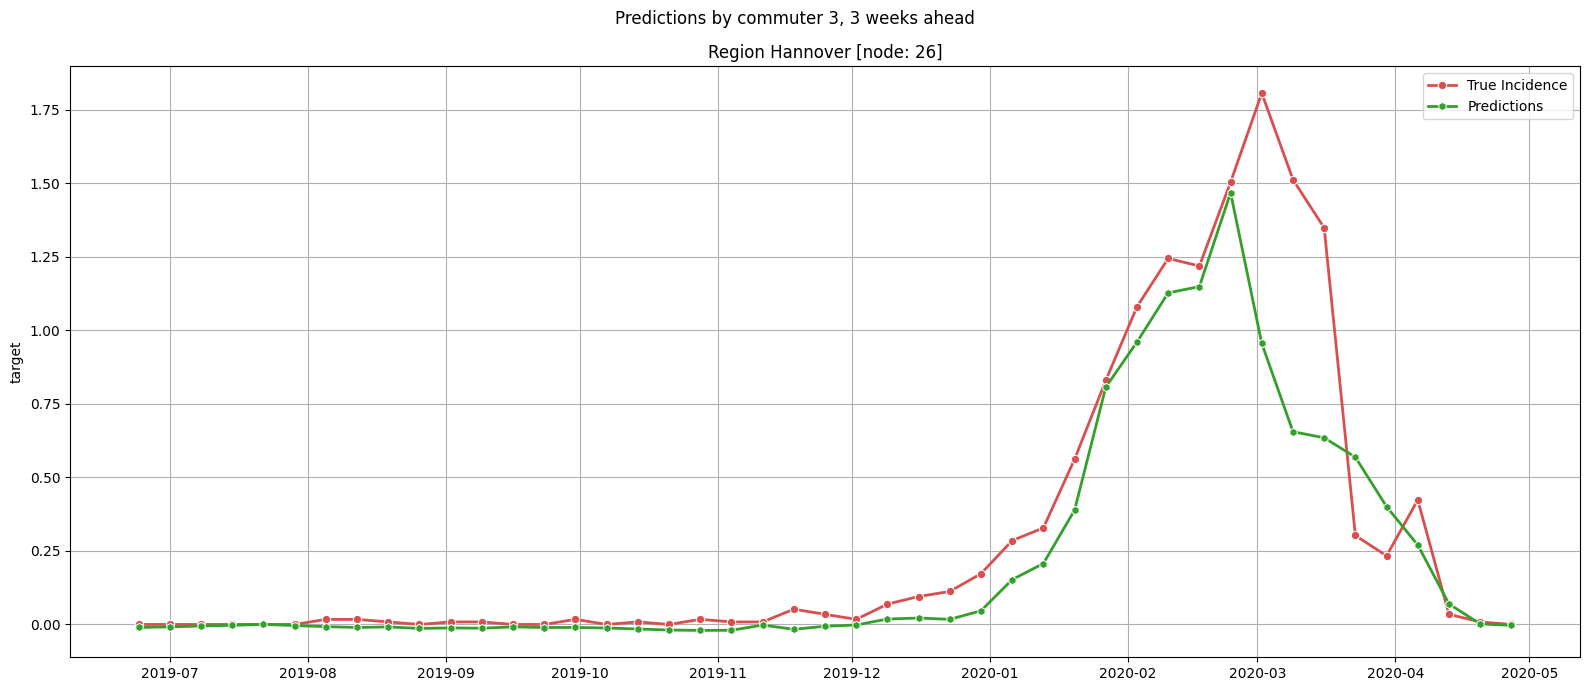

In [7]:
from src.UPDATED_models.deep.spatialgnnmodel import SpatialGNNModel
spatial_model1 = SpatialGNNModel(graphdataloader_id, name = 'identity_graph')
spatial_model1.set_model_hparams()
spatial_model1.set_global_hparams(**global_hparams)
spatial_model1.train(verbose = 2)
spatial_model1.forecast('test')
spatial_model1.show_forecasts(26)

spatial_model2 = SpatialGNNModel(graphdataloader_bn, name = 'boolean neighbors')
spatial_model2.set_model_hparams()
spatial_model2.set_global_hparams(**global_hparams)
spatial_model2.train(verbose = 2)
spatial_model2.forecast('test')
spatial_model2.show_forecasts(26)

spatial_model3 = SpatialGNNModel(graphdataloader_gr1, name = 'gravity 1')
spatial_model3.set_model_hparams()
spatial_model3.set_global_hparams(**global_hparams)
spatial_model3.train(verbose = 2)
spatial_model3.forecast('test')
spatial_model3.show_forecasts(26)

spatial_model4 = SpatialGNNModel(graphdataloader_cm1, name = 'commuter 1')
spatial_model4.set_model_hparams()
spatial_model4.set_global_hparams(**global_hparams)
spatial_model4.train(verbose = 2)
spatial_model4.forecast('test')
spatial_model4.show_forecasts(26)

spatial_model5 = SpatialGNNModel(graphdataloader_gr2, name = 'gravity 2')
spatial_model5.set_model_hparams()
spatial_model5.set_global_hparams(**global_hparams)
spatial_model5.train(verbose = 2)
spatial_model5.forecast('test')
spatial_model5.show_forecasts(26)

spatial_model6 = SpatialGNNModel(graphdataloader_cm2, name = 'commuter 3')
spatial_model6.set_model_hparams()
spatial_model6.set_global_hparams(**global_hparams)
spatial_model6.train(verbose = 2)
spatial_model6.forecast('test')
spatial_model6.show_forecasts(26)

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.47s/it]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


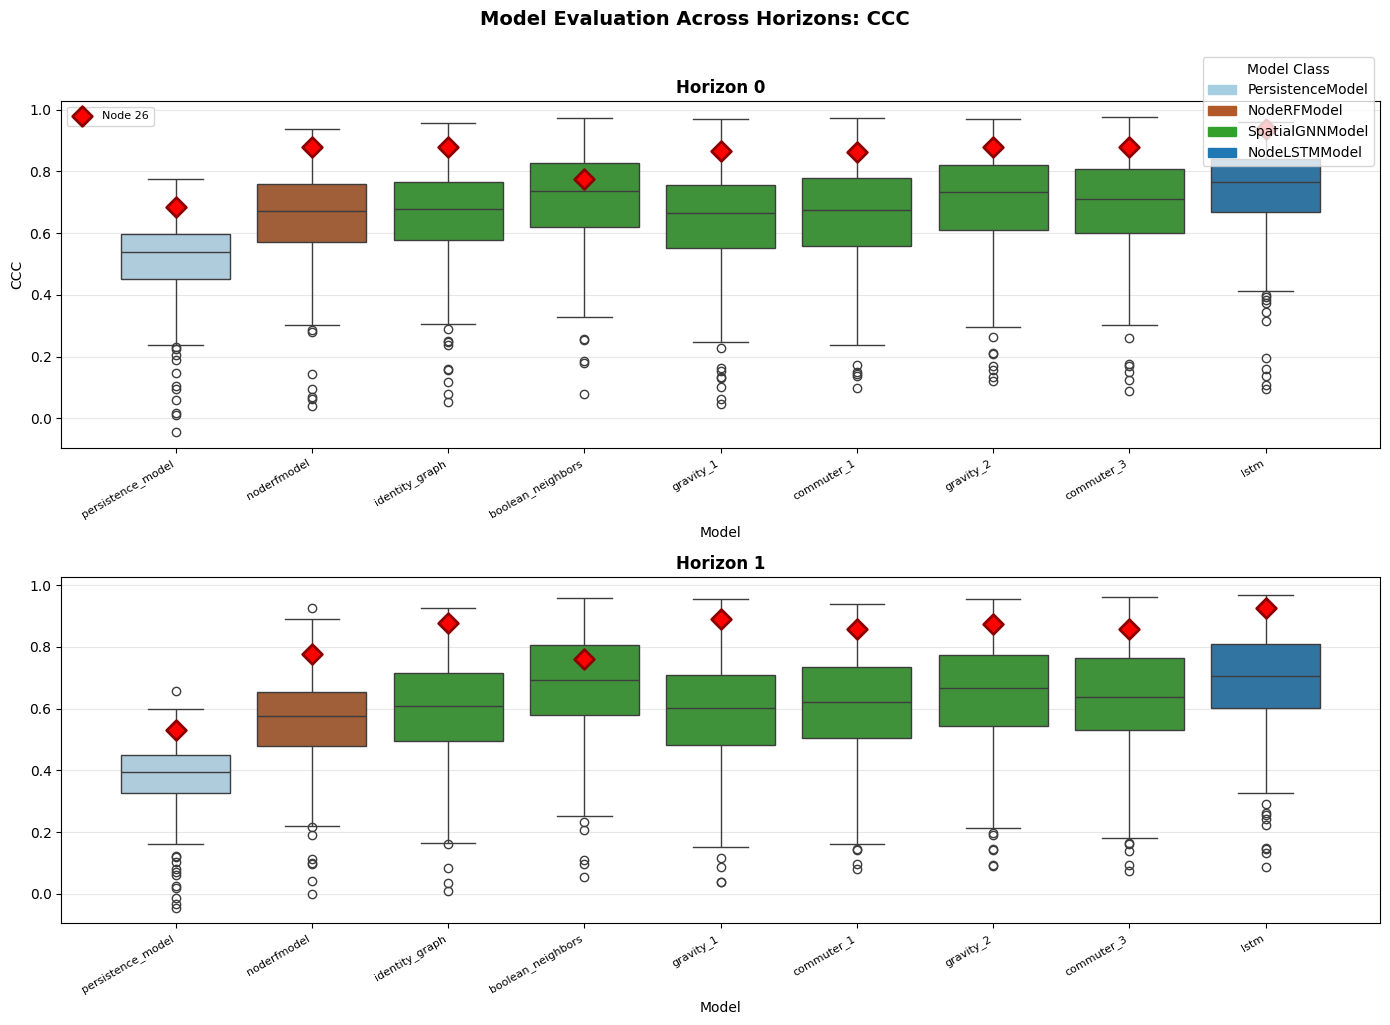

In [9]:
from src.UPDATED_evaluation.evaluator import Evaluator
evaluation = Evaluator([persistence, rf, spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6, lstm])
evaluation.add_evaluation(0, 'test')
evaluation.add_evaluation(1, 'test')

evaluation.plotter.plot_metric_horizons_separate('ccc', horizons = [0,1], plot_type='box', highlight_node=26)

In [10]:
from typing import Union, List, Literal, Union, Optional, Dict
import pandas as pd
from tqdm import tqdm 

from src.evaluation.metrics import Metrics
from src.utils.textformatting import align
from src.UPDATED_models.base.basemodel import BaseModelUPDATED
from src.UPDATED_evaluation.evaluationplotter import EvaluationPlotter
from src.UPDATED_evaluation.containers import PredictionCompilation, MetricCompilation


class Evaluator:

    """
    Evaluates models on spatiotemporal epidemioligal predictions

    Examples:
    --------
    >>> evaluator = Evaluator([ml1, ml2])
    >>> evaluator.add_evaluation()
    >>> evaluator.plotter.plot_metric("ccc", plot_type = "map")

    See Also:
    --------
    EvaluationPlotter
    Metrics
    """

    def __init__(self, models: Union[BaseModelUPDATED, List[BaseModelUPDATED]]):
        models_list             = models if isinstance(models, list) else [models]
        self.evaluated_models   = {ml.clean_name: ml for ml in models_list}
        
        # Column names
        self.target_col     = 'target'
        self.pred_col       = 'pred'
        self.id_col         = 'node'
        self.temporal_col   = 'timestamp'
        
        # Storage
        self.evaluation_entries: Dict[str, pd.DataFrame]         = {}
        self.metrics = ['mse','rmse','spearman_corr','ccc','node_smape']


        self.plotter = EvaluationPlotter(self)

        self.prediction_compilations = PredictionCompilation()
        self.metric_compilations     = MetricCompilation()
            
    def add_evaluation(self, 
                       horizon:     int  = 0,
                       dataset:     Literal['train', 'val', 'test'] = 'test') -> 'Evaluator':
        """
        Add evaluation entry for specified horizon.
        
        Parameters:
        -----------
        horizon : int
            Prediction horizon
        dataset : str
            Which dataset to evaluate
        """
        compilation_preds   = self._compile_predictions(horizon, dataset)
        self.prediction_compilations.add_horizon(compilation_preds, f'horizon_{horizon}', dataset)

        # compute metrics
        compilation_metrics = self._compile_metrics(horizon, dataset)
        self.metric_compilations.add_horizon(compilation_metrics, f'horizon_{horizon}', dataset)

        return self

    def _get_metrics_calculator(self, model: BaseModelUPDATED) -> Metrics:
        """Create metrics calculator with model's graph structure."""
        edge_index  = getattr(model.dataloadermanager, 'edge_index', None)
        edge_weight = getattr(model.dataloadermanager, 'edge_weight', None)
        
        return Metrics(
            target_col  = self.target_col,
            pred_col    = self.pred_col,
            id_col      = self.id_col,
            temporal_col= self.temporal_col,
            edge_index  = edge_index,
            edge_weight = edge_weight
        )

    def _compile_metrics(self, horizon, dataset) -> dict:
        metrics_dict = {}
        for metric_name in tqdm(self.metrics, desc = 'computing metrics'):
            metric_df = self._compute_all_models_metric(
                metric_name, horizon, dataset
            )
            metrics_dict[metric_name] = metric_df
        return metrics_dict

    def _compile_predictions(self, horizon, dataset) -> pd.DataFrame:
        predictions_compilation = None

        for name, model in self.evaluated_models.items():
            model_predictions = model.predictions.get_preds(dataset).get_original(horizon).rename(columns = {'pred' : f'pred_{name}'})
            if predictions_compilation is None:
                predictions_compilation= model_predictions
            else:
                predictions_compilation = pd.merge(predictions_compilation, model_predictions[['timestamp','node',f'pred_{name}']], on = ['timestamp','node'])

        if predictions_compilation is None:
            raise IndexError(f'predictions_compilation is invalid')        
        
        return predictions_compilation

    def _compute_standard_metric(self, df: pd.DataFrame, 
                                 metric_name: str, 
                                 model: BaseModelUPDATED) -> pd.DataFrame:
        """Compute standard metric per node using groupby."""
        calculator  = self._get_metrics_calculator(model)
        metric_func = getattr(calculator, metric_name)
        
        # Drop id_col before groupby to avoid the warning
        df_for_grouping = df.drop(columns=[self.id_col])
        
        return (
            df_for_grouping
            .groupby(df[self.id_col])  # Group by the original column
            .apply(metric_func)
            .rename(metric_name)
            .reset_index()
        )
   
    def _compute_all_models_metric(self, 
                                   metric_name: str,
                                   horizon,
                                   dataset) -> pd.DataFrame:
        """Compute specified metric for all models."""
        metric_df = None
        
        for name, model in self.evaluated_models.items():
            model_predictions = model.predictions.get_preds(dataset).get_original(horizon)

            # Route to appropriate computation method
            result = self._compute_standard_metric(model_predictions, metric_name, model)

            result.columns.values[-1] = name
            
            if metric_df is None:
                metric_df = result
            else:
                metric_df = pd.merge(metric_df, result, on=[self.id_col])

        if metric_df is None:
            raise ValueError('No metric dataframe found. Something is wrong in the evaluation datasets')
                
        return metric_df

computing metrics:   0%|                                                                                                                                                                | 0/5 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.46s/it]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


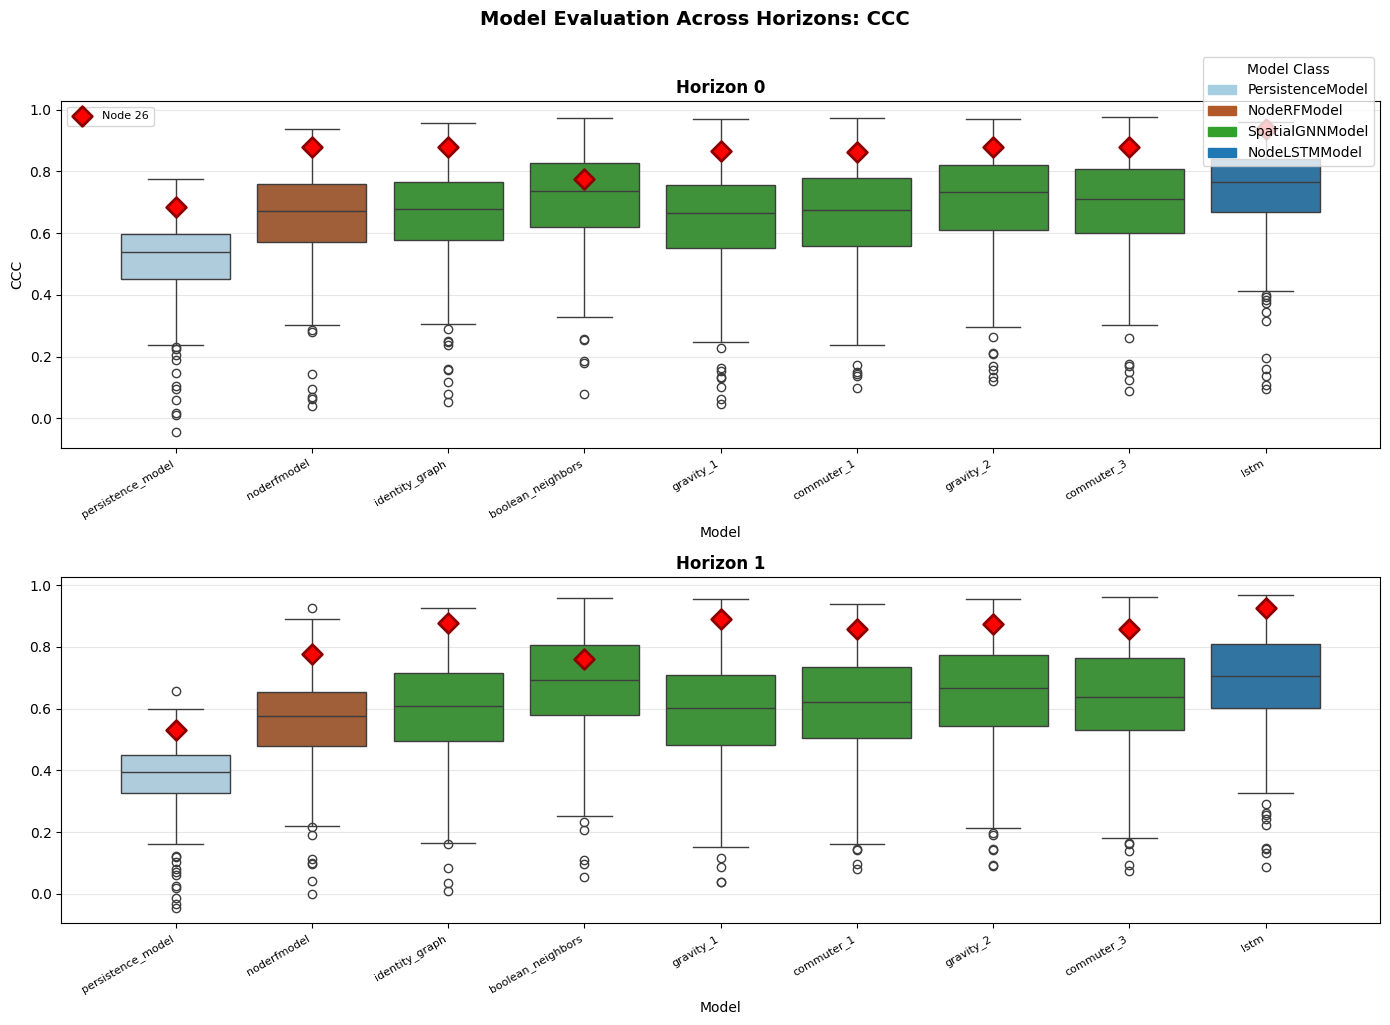

In [11]:
evaluation_spatialmodels = Evaluator([persistence, rf, spatial_model1, spatial_model2, spatial_model3, spatial_model4, spatial_model5, spatial_model6, lstm])
evaluation_spatialmodels.add_evaluation(0, 'test')
evaluation_spatialmodels.add_evaluation(1, 'test')
evaluation_spatialmodels.plotter.plot_metric_horizons_separate('ccc', horizons = [0,1], plot_type='box', highlight_node=26)

In [12]:
# lstm, boolean neighbors (spatial and spatiotemporal), commuter 3 (twice)

spatiotemporal_model2.name = 'GATv2-boolean_neighbors'
spatiotemporal_model6.name = 'GATv2-commuter_3'

spatial_model1.name = 'GCN-identity_graph'
spatial_model2.name = 'GCN-boolean_neighbors'
spatial_model6.name = 'GCN-commuter_3'

models = [spatial_model1,spatial_model6, spatiotemporal_model6]

best_evaluation = Evaluator(models)
best_evaluation.add_evaluation(0, 'test')
best_evaluation.add_evaluation(1, 'test')
ccc                     = best_evaluation.metric_compilations.get_compilation('horizon_0','test')['ccc'].dropna()
n = 3

ccc['mean']             = ccc.iloc[:, 1:].mean(axis=1)
ccc_sorted              = ccc.sort_values(by = 'mean')
min_nodes, max_nodes    = list(ccc_sorted[0:n]['node'].unique()),list(ccc_sorted[-n:]['node'].unique())

lstm_color = lstm.model_color
gcn_color  = spatial_model1.model_color
gatv2_color= spatiotemporal_model1.model_color

computing metrics:   0%|                                                                                                                                                                | 0/5 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.02it/s]
/local/job_22673904/ipykernel_3223629/4131823916.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ccc['mean']             = ccc.iloc[:, 1:].mean(axis=1)


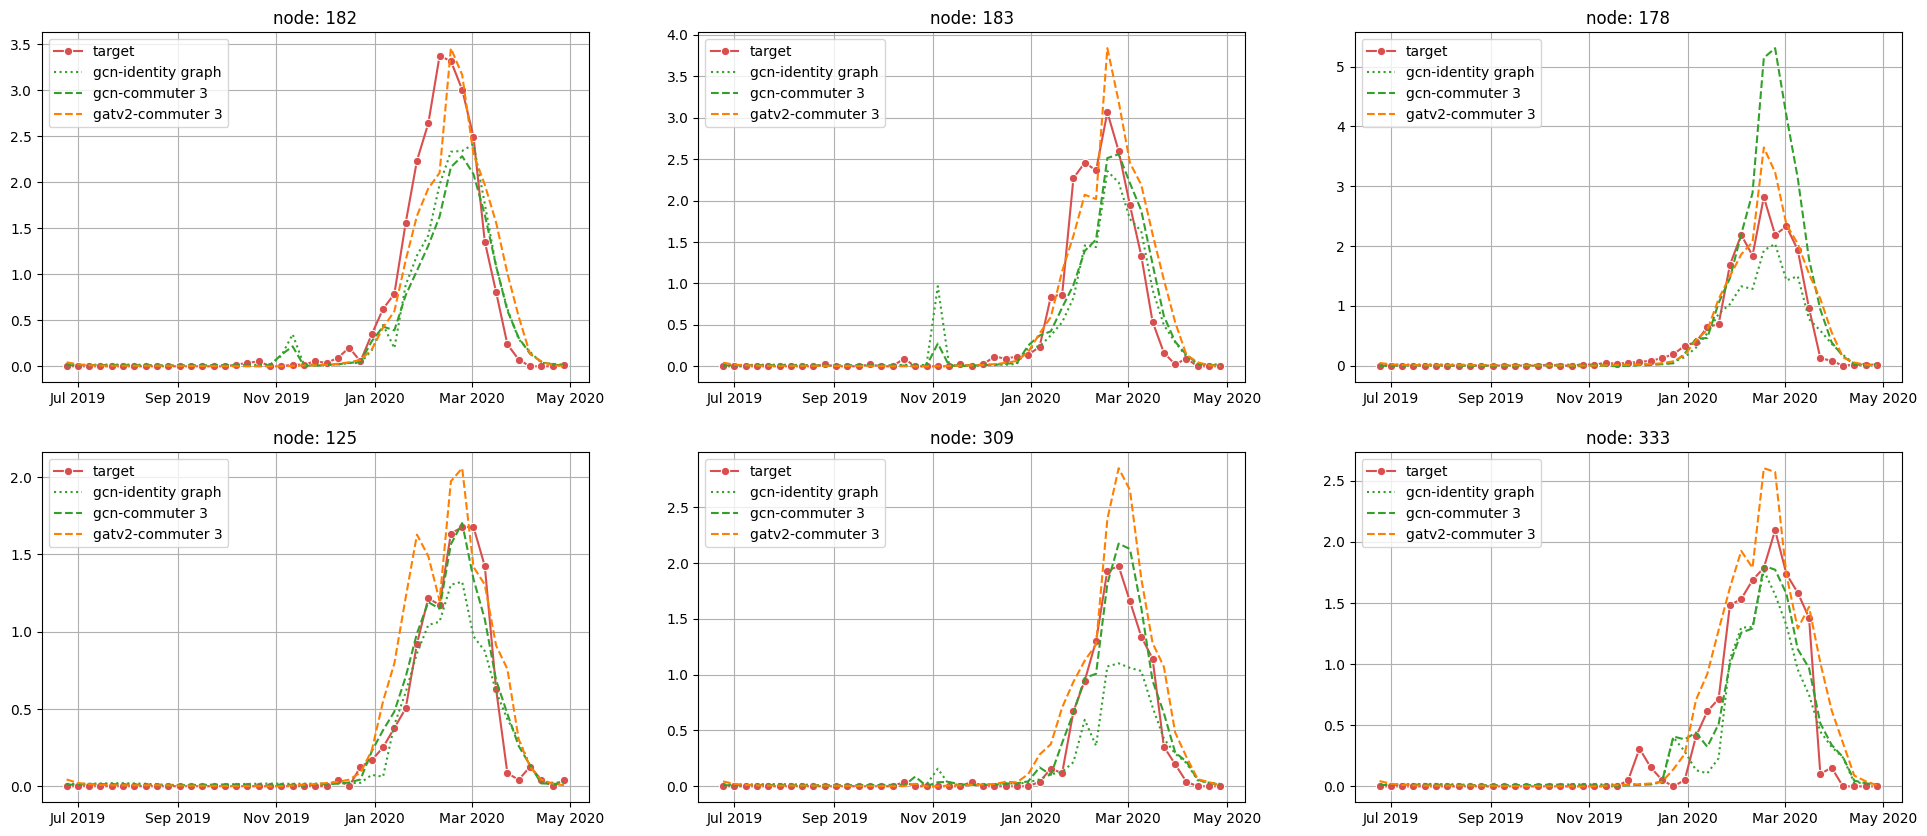

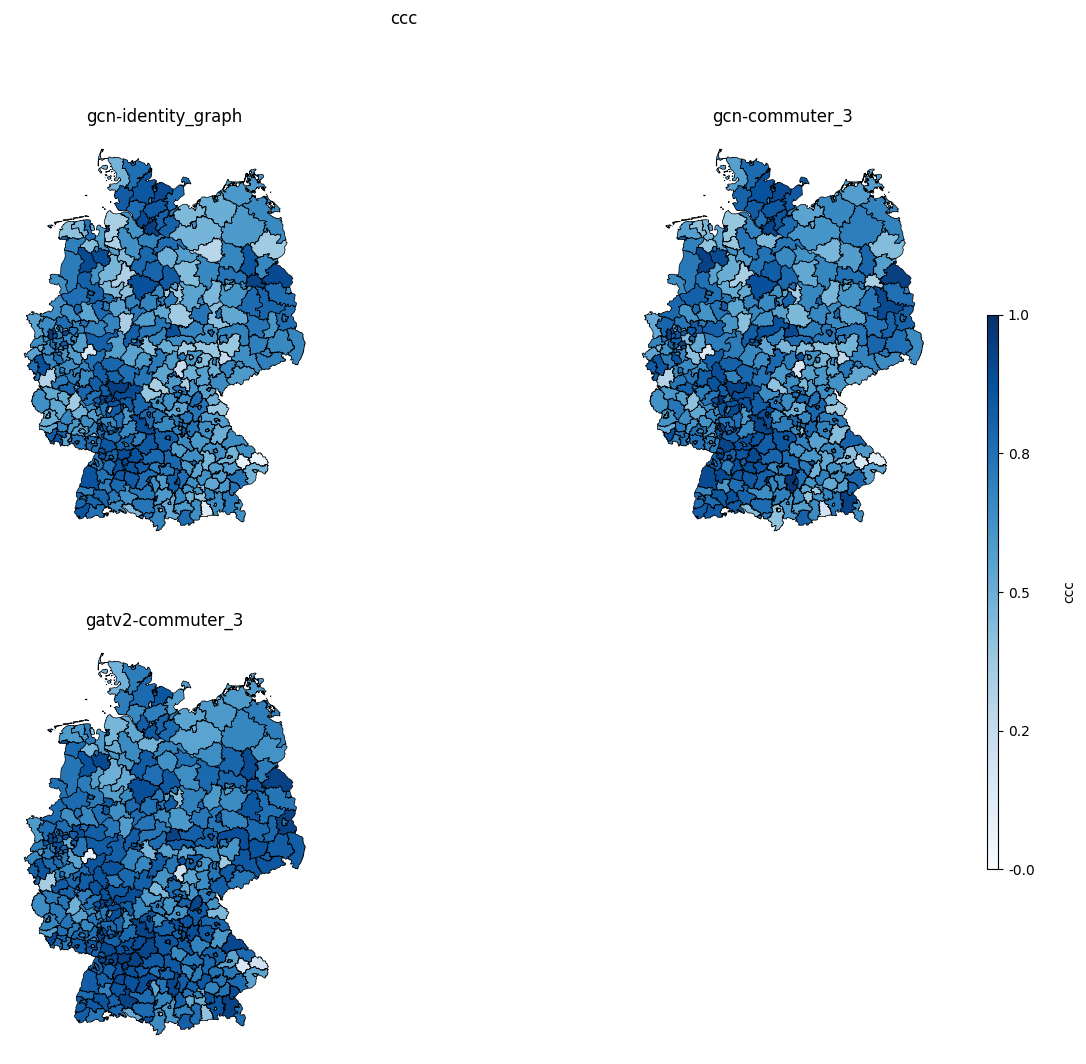

In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns
from src.utils import testcolor
import matplotlib.dates as mdates


preds_compi = best_evaluation.prediction_compilations.get_compilation('horizon_0','test')

fig, axes = plt.subplots(2, 3, figsize = (24,10))
axes      = axes.flatten()

nodes = [182, 183, 178, 125, 309, 333]


for idx, node_id in enumerate(nodes):  
    node_data = preds_compi[preds_compi['node'] == node_id]
    ax        = axes[idx]
    sns.lineplot(node_data, x = 'timestamp', y = 'target',                          color = testcolor,          label = 'target',               marker = 'o',       ax = ax)
    sns.lineplot(node_data, x = 'timestamp', y = 'pred_gcn-identity_graph',             color = gcn_color, linestyle = ":",         label = 'gcn-identity graph',                   ax = ax)       
    sns.lineplot(node_data, x = 'timestamp', y = 'pred_gcn-commuter_3',             color = gcn_color, linestyle = "--",         label = 'gcn-commuter 3',                   ax = ax)   
    sns.lineplot(node_data, x = 'timestamp', y = 'pred_gatv2-commuter_3',           color = gatv2_color, linestyle = "--",       label = 'gatv2-commuter 3',                 ax = ax)   
    ax.grid()
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f'node: {node_id}')     
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # 2-month interval
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

best_evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0', plot_type = 'map')

Text(0.5, 1.0, 'node: 178')

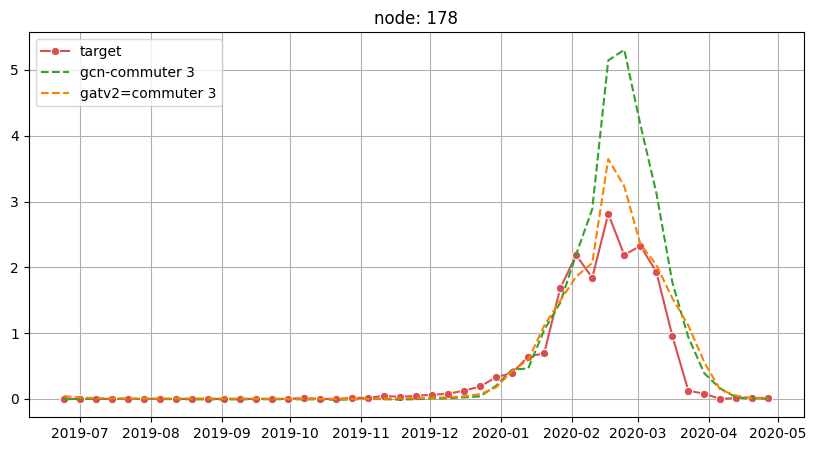

In [14]:
fig, ax = plt.subplots(1,1, figsize = (10,5))
node_id = 178
node_data = preds_compi[preds_compi['node'] == node_id]
# ax        = axes[idx]
sns.lineplot(node_data, x = 'timestamp', y = 'target',                          color = testcolor,          label = 'target',               marker = 'o',       ax = ax)
  
sns.lineplot(node_data, x = 'timestamp', y = 'pred_gcn-commuter_3',             color = gcn_color, linestyle = "--",       label = 'gcn-commuter 3',                   ax = ax)     
sns.lineplot(node_data, x = 'timestamp', y = 'pred_gatv2-commuter_3',           color = gatv2_color, linestyle = "--",       label = 'gatv2=commuter 3',                 ax = ax)   
ax.grid()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f'node: {node_id}')     

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.57s/it]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


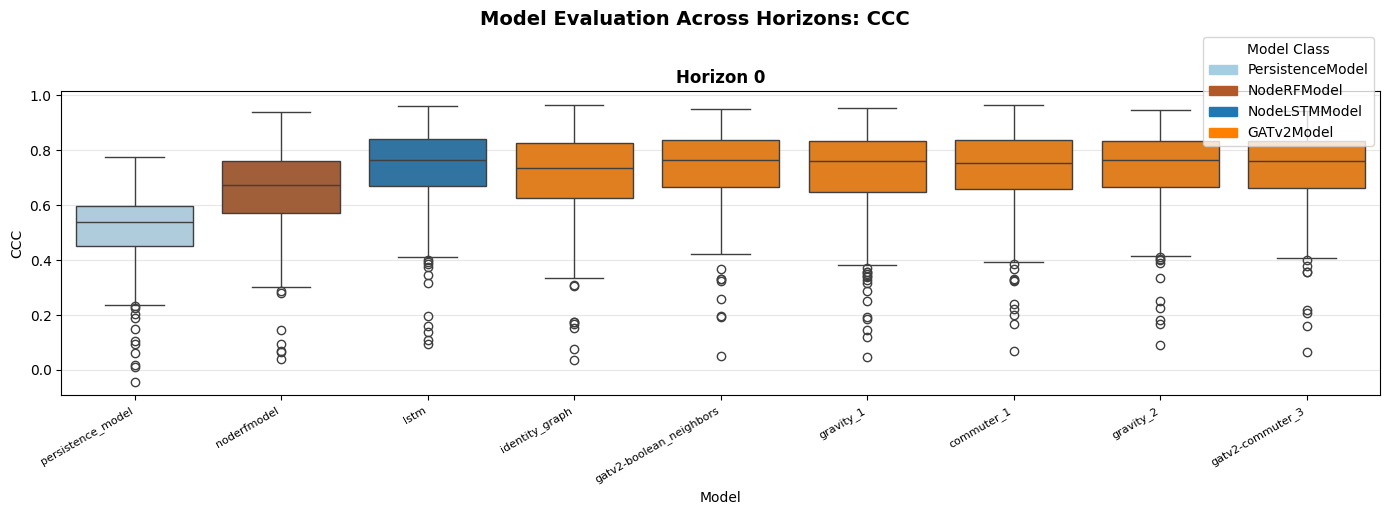

In [23]:
from src.UPDATED_evaluation.evaluator import Evaluator
spatiotemporal_evaluation = Evaluator([persistence, rf, lstm, spatiotemporal_model1, spatiotemporal_model2, spatiotemporal_model3, spatiotemporal_model4, spatiotemporal_model5, spatiotemporal_model6])
spatiotemporal_evaluation.add_evaluation(0, 'test')
# spatiotemporal_evaluation.add_evaluation(1, 'test')

spatiotemporal_evaluation.plotter.plot_metric_horizons_separate('ccc', horizons = [0], plot_type='box')

/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)


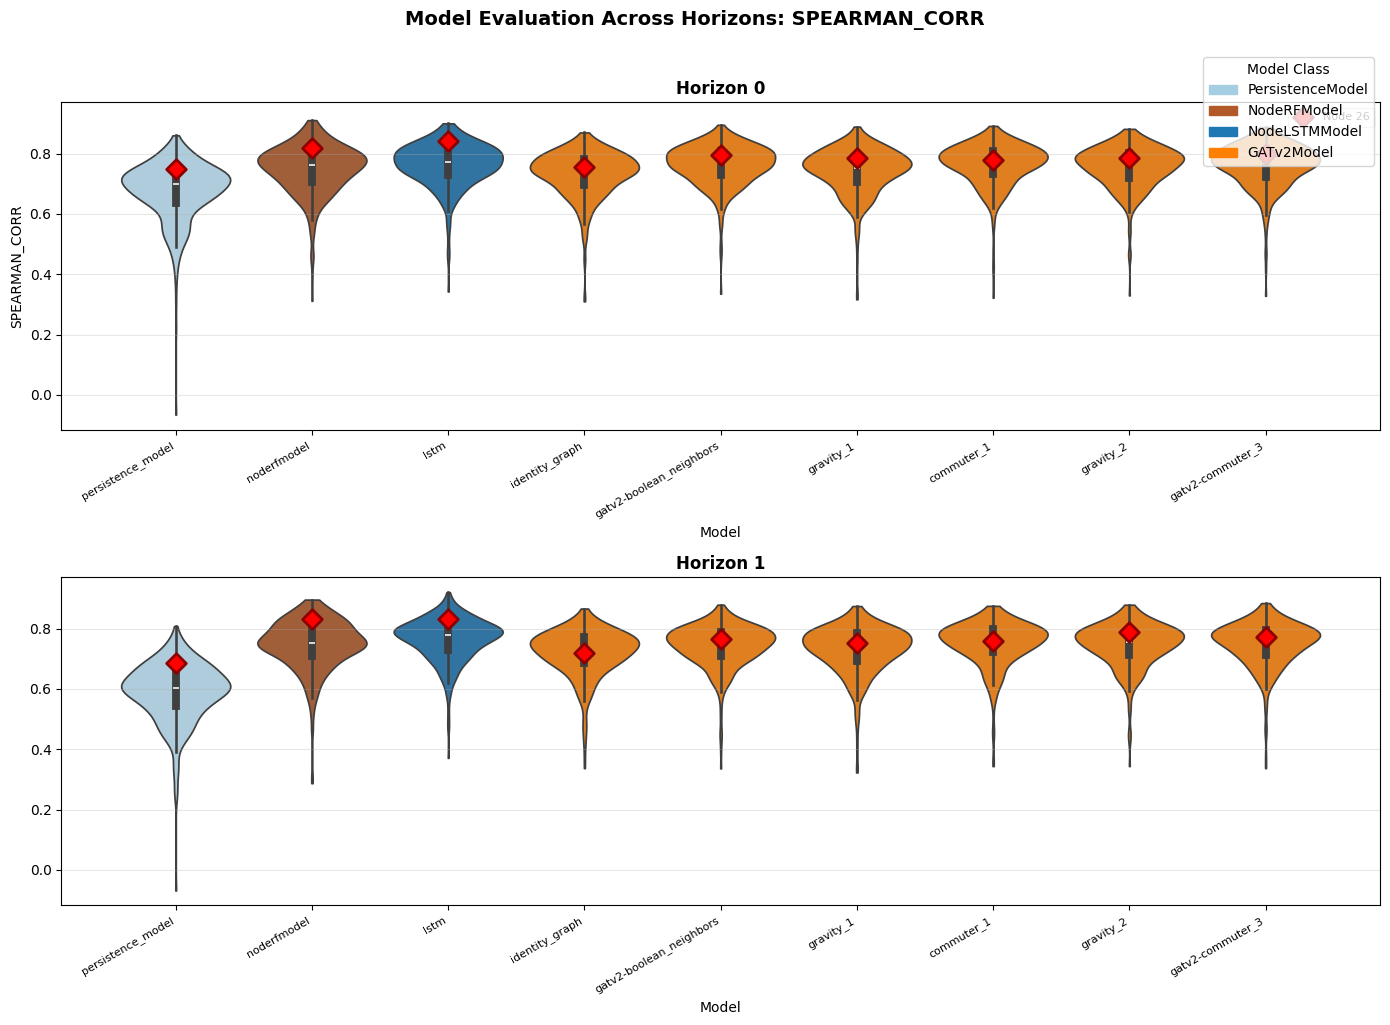

In [19]:
spatiotemporal_evaluation.plotter.plot_metric_horizons_separate('spearman_corr', horizons = [0,1], plot_type='violin', highlight_node=26)

In [ ]:
# show timeseries of the 3 best and 3 worst nodes